In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
SPLICE_CLASS_NAMES = ["Donor+", "Acceptor+", "Donor-", "Acceptor-"]
BACKGROUND_CLASS = 4
CLASS_LABELS = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
CLASS_COLORS  = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}

TISSUE_COLORS = {
    'Brain': '#3399cc',
    'Midbrain': '#34b3e6',
    'Cerebellum': '#34ccff',
    'Heart': '#cc0100',
    'Kidney': '#cc9900',
    'Liver': '#339900',
    'Ovary': '#cc329a',
    'Testis': '#ff6600'
}

SPECIES_ORDER = ['human', 'mouse', 'rat', 'rabbit', 'opossum', 'chicken'] # 'macaque'
TISSUE_ORDER = ["Brain", "Midbrain", "Cerebellum", "Heart", "Kidney", "Liver", "Ovary", "Testis"]

sci_sps = {
    "human": "Homo_sapiens",
    "mouse": "Mus_musculus",
    "rat": "Rattus_norvegicus",
    "rabbit": "Oryctolagus_cuniculus",
    "opossum": "Monodelphis_domestica",
    "chicken": "Gallus_gallus"
}

work_dir = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/"
ann_data_dir = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/"
model = "132kb_intersect_human_mouse_rat_rabbit_opossum"
subsets = ["gtf", "usage", "union", "intersect"]
pred_dir = "union"

## Load splice site classification metrics for subsets of splice sites by source

In [3]:
import os
import json

evals = {}
for pd_key in subsets:
    data_dir = os.path.join(work_dir, model, "preds_" + pd_key)

    for species in ["human", "mouse", "rat", "rabbit", "opossum"]:
        if species not in evals:
            evals[species] = {}
        if pd_key not in evals[species]:
            evals[species][pd_key] = {"sites": {}, "auprc": {}, "usage": {}}
        pred_file = os.path.join(data_dir, species, "metrics.json")
        if os.path.exists(pred_file):
            with open(pred_file, "r") as f:
                metrics = json.load(f)

            sp_metrics = metrics.get(species, {})
            per_class_auprc = sp_metrics.get("per_class_auprc", {}) or {}
            per_class_positives = sp_metrics.get("per_class_n_positives", {}) or {}
            evals[species][pd_key]['sites'] = per_class_positives
            auprc = dict(per_class_auprc)
            auprc["binary"] = sp_metrics.get("binary_auprc", None)
            evals[species][pd_key]['auprc'] = auprc
            overall_cor = sp_metrics.get("usage_by_head", {}).get("same_species", None)
            tissue_cor = sp_metrics.get("per_tissue_by_head", {}).get("same_species", None)
            all_cors = {
                "overall": overall_cor,
                "tissue": tissue_cor
            }
            evals[species][pd_key]['usage'] = all_cors
        else:
            print(f"Predictions for {species} in preds_{pd_key} are missing.")

In [4]:
evals['human']['gtf']

{'sites': {'Donor+': 3363,
  'Acceptor+': 3349,
  'Donor-': 3312,
  'Acceptor-': 3345},
 'auprc': {'Donor+': 0.6798793406666825,
  'Acceptor+': 0.6558139311890931,
  'Donor-': 0.6954108949386683,
  'Acceptor-': 0.6828219228763893,
  'binary': 0.6737226448979586},
 'usage': {'overall': {'usage_pearson_r': 0.7577154040336609,
   'usage_mean_pearson_r': 0.6790557590482588,
   'usage_median_pearson_r': 0.7169325351715088,
   'usage_n_conditions_evaluated': 88,
   'usage_n_conditions_total': 88,
   'usage_n_observations': 656128},
  'tissue': {'Brain': {'n_conditions': 15,
    'mean_pearson_r': 0.6448891697989365,
    'median_pearson_r': 0.7073879375057163,
    'std_pearson_r': 0.19650874699854337},
   'Cerebellum': {'n_conditions': 12,
    'mean_pearson_r': 0.493493498325251,
    'median_pearson_r': 0.6406575353361179,
    'std_pearson_r': 0.2596100691963399},
   'Heart': {'n_conditions': 12,
    'mean_pearson_r': 0.7163223722467622,
    'median_pearson_r': 0.7043489978156717,
    'std_pea

Number of sites per class for each species (rows) and subset (columns).

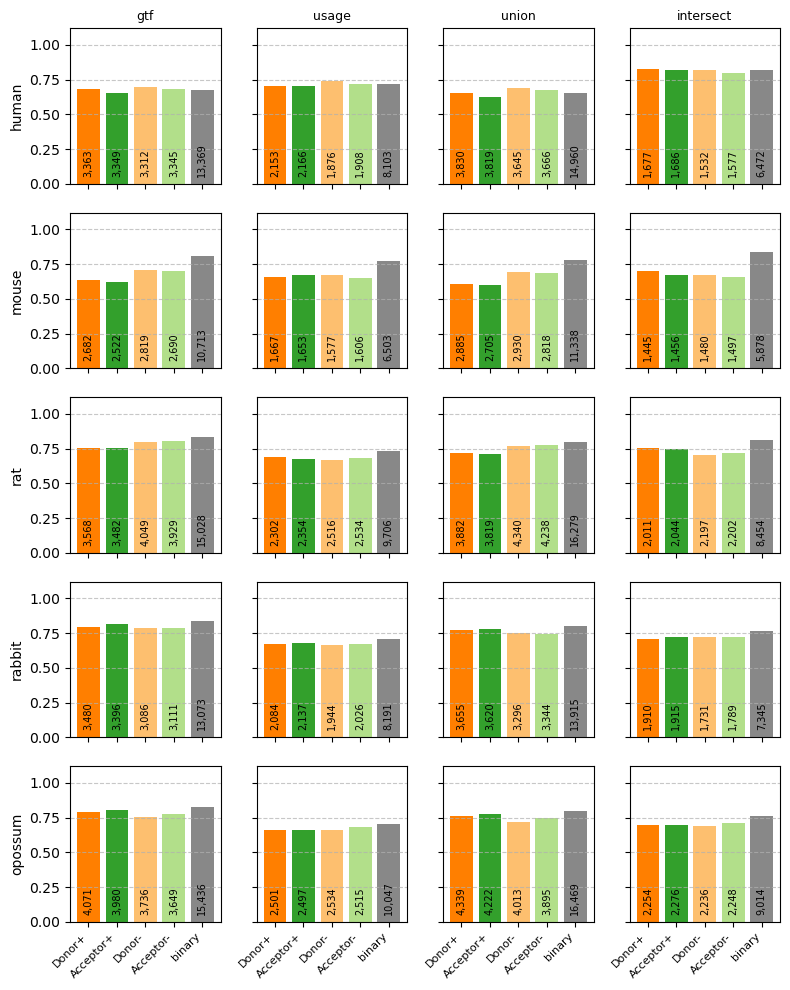

In [5]:
import numpy as np
import matplotlib.pyplot as plt

species_list = [s for s in SPECIES_ORDER if s in evals]
subsets_list = [s for s in subsets if any(evals[sp].get(s) is not None for sp in species_list)]
n_species = len(species_list)
n_classes = len(SPLICE_CLASS_NAMES) + 1  # +1 for binary
n_preds = len(subsets_list)
import numpy as np
# Add site-count annotations automatically before saving/showing the figure
def _annotate_site_counts(fig):
    if fig is None:
        return

    axs = np.array(fig.axes, dtype=object).reshape(n_species, n_preds)
    keys = SPLICE_CLASS_NAMES + ["binary"]

    for row, sp in enumerate(species_list):
        for col, pd_key in enumerate(subsets_list):
            ax = axs[row, col]

            # Avoid duplicate labels if both savefig() and show() are called
            if getattr(ax, "_site_labels_added", False):
                continue

            site_map = evals.get(sp, {}).get(pd_key, {}).get("sites", {}) or {}
            class_counts = [site_map.get(k, np.nan) for k in SPLICE_CLASS_NAMES]
            binary_count = np.nansum(class_counts) if len(class_counts) else np.nan
            counts = class_counts + [binary_count]

            # Bars in this axis correspond to keys order
            bars = ax.patches[:len(keys)]
            for bar, n in zip(bars, counts):
                if np.isfinite(n):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        0.05,
                        f"{int(n):,}",
                        ha="center",
                        va="bottom",
                        fontsize=7,
                        rotation=90
                    )

            ax.set_ylim(0, 1.12)
            ax._site_labels_added = True


# Patch savefig/show so labels are present both on disk and on-screen
if not hasattr(plt, "_orig_savefig"):
    plt._orig_savefig = plt.savefig
if not hasattr(plt, "_orig_show"):
    plt._orig_show = plt.show

def _savefig_with_site_labels(*args, **kwargs):
    _annotate_site_counts(plt.gcf())
    return plt._orig_savefig(*args, **kwargs)

def _show_with_site_labels(*args, **kwargs):
    _annotate_site_counts(plt.gcf())
    return plt._orig_show(*args, **kwargs)

plt.savefig = _savefig_with_site_labels
plt.show = _show_with_site_labels

fig, axes = plt.subplots(n_species, n_preds, figsize=(n_preds * 2, n_species * 2), sharey='row', sharex=True)

for row, sp in enumerate(species_list):
    for col, pd_key in enumerate(subsets_list):
        ax = axes[row, col]
        sp_data = evals.get(sp, {})
        auprc_data = sp_data.get(pd_key, None).get('auprc', None) if sp_data else None
        if auprc_data is not None:
            keys = SPLICE_CLASS_NAMES + ['binary']
            values = [auprc_data.get(k, np.nan) for k in keys]
            colors = [CLASS_COLORS[i] for i in range(len(SPLICE_CLASS_NAMES))] + ['#888888']
            bars = ax.bar(keys, values, color=colors)
            ax.set_ylim(0, 1)
            ax.set_xticks(range(len(keys)))
            ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=8)
            ax.grid(axis='y', linestyle='--', alpha=0.7)
        if row == 0:
            ax.set_title(f'{pd_key}' if pd_key else '', fontsize=9)
        if col == 0:
            ax.set_ylabel(sp, fontsize=10)

plt.tight_layout()

# Save plot
plt.savefig(os.path.join(work_dir, model, "prediction_splice_site_auprc_by_subsets.png"), dpi=300)
plt.show()

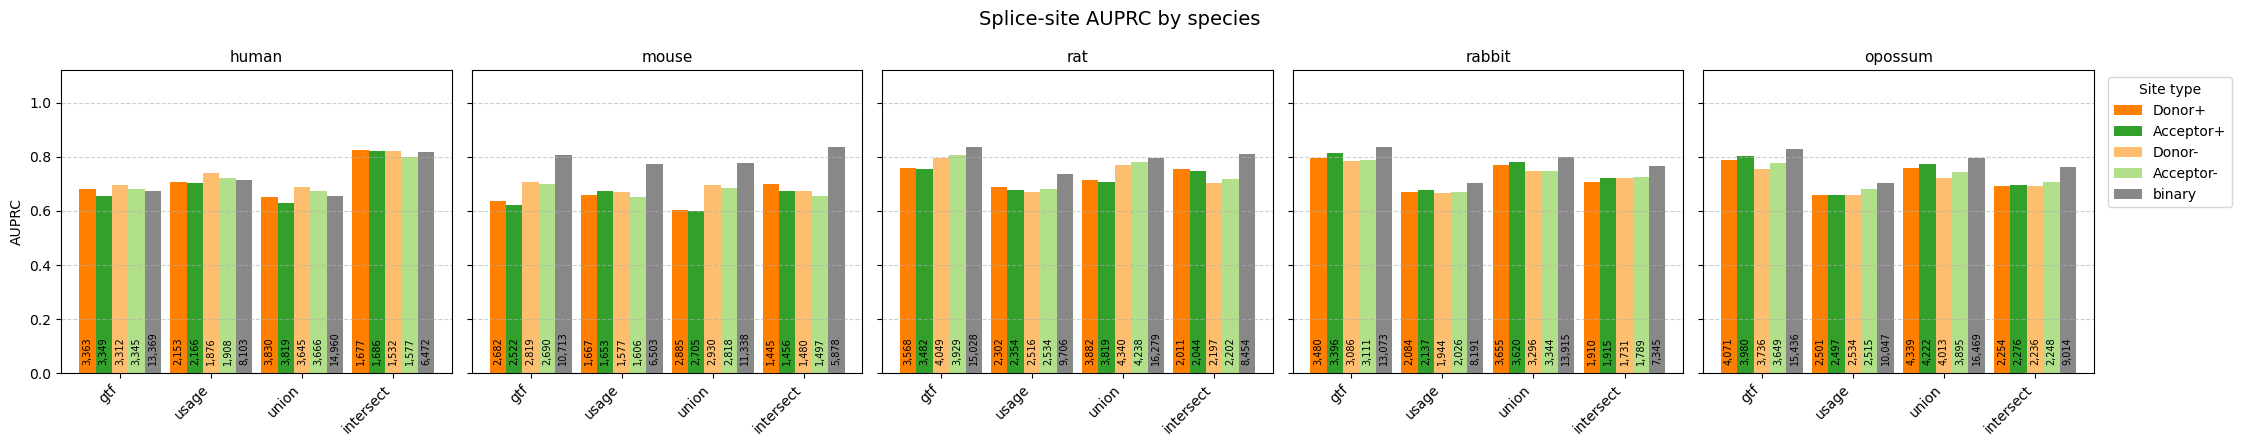

In [7]:
class_keys = SPLICE_CLASS_NAMES + ["binary"]
species_plot = [s for s in SPECIES_ORDER if s in evals]
subset_plot = [s for s in subsets if any(evals[sp].get(s) is not None for sp in species_plot)]

fig, axes = plt.subplots(
    1, len(species_plot),
    figsize=(len(species_plot) * 4.5, 4.5),
    sharey=True,
    squeeze=False
)

axes = axes[0]

x_subset = np.arange(len(subset_plot))
bar_width = 0.9 / max(len(class_keys), 1)
class_colors = [CLASS_COLORS[i] for i in range(len(SPLICE_CLASS_NAMES))] + ["#888888"]

for ax, sp in zip(axes, species_plot):
    for j, class_key in enumerate(class_keys):
        values = []
        counts = []

        for subset in subset_plot:
            subset_data = evals.get(sp, {}).get(subset, {})
            auprc_map = subset_data.get("auprc", {}) if subset_data is not None else {}
            site_map = subset_data.get("sites", {}) if subset_data is not None else {}

            values.append(auprc_map.get(class_key, np.nan))

            if class_key == "binary":
                cls_counts = [site_map.get(k, np.nan) for k in SPLICE_CLASS_NAMES]
                n_sites = np.nansum(cls_counts) if len(cls_counts) else np.nan
            else:
                n_sites = site_map.get(class_key, np.nan)
            counts.append(n_sites)

        offsets = x_subset + (j - (len(class_keys) - 1) / 2) * bar_width
        bars = ax.bar(offsets, values, width=bar_width, color=class_colors[j], label=class_key)

        # annotate n sites on each bar
        for bar, n in zip(bars, counts):
            if np.isfinite(n):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    0.03,
                    f"{int(n):,}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    rotation=90
                )

    ax.set_title(sp, fontsize=11)
    ax.set_xticks(x_subset)
    ax.set_xticklabels(subset_plot, rotation=45, ha="right")
    ax.set_ylim(0, 1.12)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

axes[0].set_ylabel("AUPRC")
axes[-1].legend(title="Site type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle("Splice-site AUPRC by species", fontsize=14)
plt.tight_layout()

fig.savefig(
    os.path.join(work_dir, model, "prediction_splice_site_auprc_by_subset_grouped.png"),
    dpi=300,
    bbox_inches="tight"
)

## Evaluate splice site classification metrics for subsets of splice sites by functional annotation

Load splice site classification predictions and labels for each species and subset.

In [43]:
import os
import json

save = False
evals = {}

pd_key = "union"
data_dir = os.path.join(work_dir, model, f"preds_{pd_key}")

for species in ["human", "mouse", "rat", "rabbit", "opossum"]: 

    if species not in evals:
        
        evals[species] = {}
        
        # Load predictions
        pred_file = os.path.join(data_dir, species, f"predictions_{species}.npz")
        if os.path.exists(pred_file):
            preds = np.load(pred_file)
        else:
            print(f"Predictions for {species} in preds_{pd_key} are missing.")
            continue        
        print(f"Loaded predictions for {species}: {preds.keys()}")

        # Load genomic intervals for each prediction
        bed_file = os.path.join(data_dir, species, f"sampled_windows_{species}.bed")
        if os.path.exists(bed_file):
            bed_df = pd.read_csv(bed_file, sep="\t", index_col=False, header=None, names=["chrom", "start", "end", "strand", "mask_rel_start", "mask_rel_end"])
            bed_df['mask_start'] = bed_df['start'] + bed_df['mask_rel_start']
            bed_df['mask_end'] = bed_df['start'] + bed_df['mask_rel_end']
        else:
            print(f"BED file for {species} in preds_{pd_key} is missing.")
            continue
        
        # Build a dataframe with one row per position in each chrom:mask_start-mask_end interval
        true_cls = preds['cls_labels']
        cls_probs = preds['cls_probs']
        rows = []
        for _, row in bed_df.iterrows():
            for pos in range(row['mask_start'], row['mask_end']):
                rows.append({'chrom': row['chrom'], 'position': pos})

        positions_df = pd.DataFrame(rows)

        # Check that positions_df has the same number of rows as the total number of elements in preds['cls_probs']
        assert len(positions_df) == true_cls.shape[0], f"Mismatch between positions dataframe ({len(positions_df)}) and predictions array length ({preds['cls_probs'].shape[0]})"

        # Add true labels
        positions_df['class_label'] = true_cls

        # Add predicted probabilities for each class
        for i, class_name in enumerate(class_keys):
            positions_df[f'prob_{i}'] = cls_probs[:, i]

        # Add predicted class based on highest probability
        positions_df['predicted_class_label'] = positions_df[[f'prob_{i}' for i in range(len(class_keys))]].idxmax(axis=1).apply(lambda x: int(x.split('_')[1]))

        print(f"Collected predictions for {species} into dataframe: {positions_df.shape[0]} positions")

        # Save to disk
        if save:
            pq_file = os.path.join(work_dir, model, pd_key, species, f"predictions_{species}.parquet")
            positions_df.to_parquet(pq_file, index=False)
            print(f"Saved predictions for {species} to parquet: {pq_file}")

        evals[species] = positions_df
        

Loaded predictions for human: KeysView(NpzFile '/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_intersect_human_mouse_rat_rabbit_opossum/preds_union/human/predictions_human.npz' with keys: cls_probs, cls_labels, loss_mask)
Collected predictions for human into dataframe: 30367529 positions
Loaded predictions for mouse: KeysView(NpzFile '/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_intersect_human_mouse_rat_rabbit_opossum/preds_union/mouse/predictions_mouse.npz' with keys: cls_probs, cls_labels, loss_mask)
Collected predictions for mouse into dataframe: 27213617 positions
Loaded predictions for rat: KeysView(NpzFile '/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_intersect_human_mouse_rat_rabbit_opossum/preds_union/rat/predictions_rat.npz' with keys: cls_probs, cls_labels, loss_mask)
Collected predictions for rat into dataframe: 32138710 positions
Loaded predictions for rabbit: KeysView(NpzFile '/home/elek/sds/sd17d003/Anamaria/alphagenome

In [44]:
# Combine all species into one dataframe for analysis
combined_df = pd.concat(evals.values(), keys=evals.keys(), names=['species', 'row_id']).reset_index(level='row_id', drop=True).reset_index()
combined_df

,species,chrom,position,class_label,prob_0,prob_1,prob_2,prob_3,prob_4,predicted_class_label
0,human,1,630896,4,0.000023,0.000587,0.000096,0.000108,1.0,4
1,human,1,630897,4,0.000136,0.000100,0.000052,0.000090,1.0,4
2,human,1,630898,0,0.000018,0.000072,0.000022,0.000456,1.0,4
3,human,1,630899,4,0.000042,0.000292,0.000043,0.000077,1.0,4
4,human,1,630900,4,0.000097,0.000912,0.000429,0.000046,1.0,4
...,...,...,...,...,...,...,...,...,...,...
186171625,opossum,X,78913202,4,0.000030,0.000021,0.000060,0.000015,1.0,4
186171626,opossum,X,78913203,4,0.000011,0.000039,0.000187,0.000020,1.0,4
186171627,opossum,X,78913204,4,0.000006,0.000008,0.000013,0.000007,1.0,4
186171628,opossum,X,78913205,4,0.000008,0.000006,0.000732,0.000687,1.0,4


In [46]:
if save:
    pq_file = os.path.join(work_dir, model, f"preds_{pd_key}", f"predictions.parquet")
    combined_df.to_parquet(pq_file, index=False)
    print(f"Saved predictions to parquet: {pq_file}")

Saved predictions to parquet: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_intersect_human_mouse_rat_rabbit_opossum/preds_union/predictions.parquet


Annotate splice sites with the transcript biotype they overlap.

In [98]:
sf

,chrom,position,class_label,prob_0,prob_1,prob_2,prob_3,prob_4,predicted_class_label,strand,gene_biotype
0,1,630898,0,0.000018,0.000072,0.000022,0.000456,1.000000,4,+,none
1,1,630923,1,0.000072,0.002457,0.000121,0.000050,0.996094,4,+,none
2,1,975711,1,0.003204,0.099609,0.001144,0.000813,0.894531,4,+,protein_coding
3,1,976268,3,0.000026,0.000835,0.000330,0.388672,0.609375,4,-,protein_coding
4,1,976498,2,0.000448,0.000090,0.625000,0.000065,0.373047,2,-,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...
14955,Y,23280012,1,0.007050,0.878906,0.000066,0.000007,0.114258,1,+,protein_coding
14956,Y,23280083,0,0.890625,0.000349,0.000005,0.000006,0.107422,0,+,protein_coding
14957,Y,23280828,1,0.011536,0.871094,0.000040,0.000007,0.117188,1,+,protein_coding
14958,Y,23280862,0,0.894531,0.000073,0.000005,0.000001,0.104492,0,+,protein_coding


In [107]:
ex = pq[pq['Feature'] == 'exon']
# class_label = 0 (donor +) --> exon end
ex[(ex['Chromosome'] == 'Y') & (ex['End'] == 23280862+1)]
# class_label = 1 (acceptor +) --> exon start
ex[(ex['Chromosome'] == '1') & (ex['Start'] == 975711)]
# class_label = 2 (donor -) --> exon start
ex[(ex['Chromosome'] == '1') & (ex['Start'] == 976498)]
# class_label = 3 (acceptor -) --> exon end
ex[(ex['Chromosome'] == '1') & (ex['End'] == 976268+1)]



,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_source,transcript_biotype,tag,transcript_support_level,exon_number,exon_id,exon_version,protein_id,protein_version,ccds_id
654954,1,ensembl_havana,exon,975197,976269,.,-,.,ENSG00000187642,11,...,ensembl_havana,protein_coding,Ensembl_canonical,5 (assigned to previous version 3),4,ENSE00003963238,1,None,None,CCDS76083
654969,1,havana,exon,975203,976269,.,-,.,ENSG00000187642,11,...,havana,protein_coding,gencode_primary,2,5,ENSE00001366612,1,None,None,CCDS90836
654977,1,havana,exon,975204,976269,.,-,.,ENSG00000187642,11,...,havana,retained_intron,NaN,1,2,ENSE00001827921,1,None,None,None
654985,1,havana,exon,976120,976269,.,-,.,ENSG00000187642,11,...,havana,protein_coding,gencode_primary,None,4,ENSE00003961240,1,None,None,CCDS76083
654998,1,havana_tagene,exon,975196,976269,.,-,.,ENSG00000187642,11,...,havana_tagene,protein_coding,gencode_primary,None,4,ENSE00004330752,1,None,None,None
655012,1,havana_tagene,exon,975197,976269,.,-,.,ENSG00000187642,11,...,havana_tagene,protein_coding,gencode_basic,None,5,ENSE00003963238,1,None,None,CCDS76083
655026,1,havana_tagene,exon,975197,976269,.,-,.,ENSG00000187642,11,...,havana_tagene,protein_coding,gencode_primary,None,4,ENSE00003963238,1,None,None,CCDS76083
655039,1,havana_tagene,exon,975200,976269,.,-,.,ENSG00000187642,11,...,havana_tagene,protein_coding,gencode_basic,None,4,ENSE00004330754,1,None,None,CCDS76083
655050,1,havana_tagene,exon,975193,976269,.,-,.,ENSG00000187642,11,...,havana_tagene,protein_coding,gencode_basic,None,3,ENSE00004452062,1,None,None,None
655061,1,havana_tagene,exon,975206,976269,.,-,.,ENSG00000187642,11,...,havana_tagene,protein_coding,gencode_basic,None,3,ENSE00004452058,1,None,None,None


In [ ]:
evals_func = {}

for sp in evals:

    if sp not in evals_func:
        evals_func[sp] = {}

    df = evals[sp]
    print(f"{sp}: {df.shape[0]} positions")

    # Subset only the splice sites
    sf = df[df['class_label'].isin([0, 1, 2, 3])]

    # Add strand: if class label in [0, 1], strand=+, if class label in [2, 3], strand=-
    sf['strand'] = sf['class_label'].apply(lambda x: "+" if x in [0, 1] else "-")

    # Order columns: chrom, position, strand, ...
    cols = ["chrom", "position", "strand"] + [s for s in sf.columns if s not in ["chrom", "position", "strand"]]

    # Reset index
    sf.reset_index(inplace=True, drop=True)
    
    # Load gene annotations
    fn = os.path.join(ann_data_dir, sci_sps[sp], f"{sci_sps[sp]}.parquet")
    pq = pd.read_parquet(fn)

    # Subset transcripts
    tq = pq[pq['Feature'] == 'exon']
    
    # Replace any row matching "pseudogene" in the "gene_biotype" column with "pseudogene"
    if "gene_biotype" in tq.columns:
        tq['gene_biotype'] = tq['gene_biotype'].apply(lambda x: "pseudogene" if "pseudogene" in x else x)
    else:
        print(f"gene_biotype column is missing in the annotation for {sp}. Available columns: {tq.columns}")
        continue

    # Reset index
    tq.reset_index(inplace=True, drop=True)

    # Top categories
    if "gene_biotype" in tq.columns:
        print(f"Top gene biotypes:")
        print(f"{tq.value_counts('gene_biotype').head()}", end="\n\n")
    else:
        print(f"gene_biotype column is missing in the annotation for {sp}. Available columns: {tq.columns}")
        continue

    # Working categories
    cats = ["protein_coding", "lncRNA", "snRNA", "miRNA", "pseudogene", "other", "none"]

    # Overlap splice sites with transcripts to assign gene biotype categories
    for idx, row in sf.iterrows():
        chr = row['chrom']
        position = row['position']
        strand = row['strand']
        label = row['class_label']
        # site_cats = tq[(tq['Chromosome'] == chr) & (tq['Start'] < position) & (tq['End'] > position) & (tq['Strand'] == strand)]['gene_biotype'].unique()
        if label == 0:
            # class label = 0 (donor +) --> exon end
            site_cats = tq[(tq['Chromosome'] == chr) & (tq['End'] == position+1) & (tq['Strand'] == strand)]['gene_biotype'].unique()
        elif label == 1:
        # class_label = 1 (acceptor +) --> exon start
            site_cats = tq[(tq['Chromosome'] == chr) & (tq['Start'] == position) & (tq['Strand'] == strand)]['gene_biotype'].unique()
        elif label == 2:
            # class_label = 2 (donor -) --> exon start
            site_cats = tq[(tq['Chromosome'] == chr) & (tq['Start'] == position) & (tq['Strand'] == strand)]['gene_biotype'].unique()
        elif label == 3:
            # class_label = 3 (acceptor -) --> exon end
            site_cats = tq[(tq['Chromosome'] == chr) & (tq['End'] == position+1) & (tq['Strand'] == strand)]['gene_biotype'].unique()

        if len(site_cats) == 0:
            site_cats = "none"
        else:
            site_cats = [cat for cat in site_cats if cat in cats]
            if len(site_cats) == 0:
                site_cats = "other"
            else:
                # make categorical and sort, keep only the first category if multiple are present
                site_cats = pd.Categorical(site_cats, categories=cats, ordered=True)
                site_cats = site_cats.sort_values()
                site_cats = site_cats[0]
        sf.loc[idx, 'gene_biotype'] = site_cats

    # Count the number of splice sites in each gene biotype category
    print(f"Splice site counts by gene biotype for {sp}:")
    print(f"{sf['gene_biotype'].value_counts()}", end="\n\n")

    # Calculate TP, FN and recall for each gene biotype category
    results = []
    for cat in cats:
        tp = len(sf[(sf['gene_biotype'] == cat) & (sf['class_label'] == sf['predicted_class_label'])])
        fn = len(sf[(sf['gene_biotype'] == cat) & (sf['class_label'] != sf['predicted_class_label']) & (sf['predicted_class_label'] == 4)]) # false negatives are those that are actually splice sites (class_label != 0) but predicted as non-splice sites (predicted_class_label == 0)
        ms = len(sf[(sf['gene_biotype'] == cat) & (sf['class_label'] != sf['predicted_class_label']) & (sf['predicted_class_label'] != 4)]) # misclassified as other class (not TP, not FN)
        assert tp + fn + ms == len(sf[sf['gene_biotype'] == cat]), f"Mismatch in counts for category {cat} in species {sp}"
        recall = tp / (tp + fn + ms) if (tp + fn + ms) > 0 else 0
        results.append({'gene_biotype': cat, 'TP': tp, 'FN': fn, 'Misclassified': ms, 'Recall': recall})
    results_df = pd.DataFrame(results)
    
    print(f"Results by gene biotype for {sp}:")
    print(results_df, end=f"\n{"=" * 50}\n")
    # Add results to evals_func
    evals_func[sp] = results_df
    


human: 30367529 positions


/tmp/ipykernel_1771382/1511380774.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sf['strand'] = sf['class_label'].apply(lambda x: "+" if x in [0, 1] else "-")


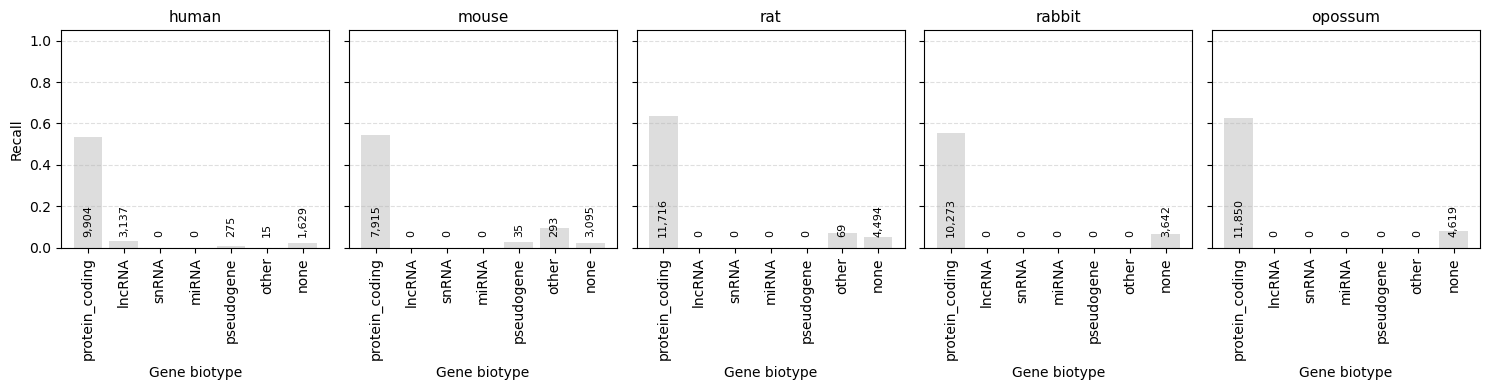

In [116]:
# Plot recall by gene biotype across species (recall on y-axis)
species_plot = [s for s in SPECIES_ORDER if s in evals_func]
fig, axes = plt.subplots(1, len(species_plot), figsize=(len(species_plot) * 3, 4), sharey=True)

if len(species_plot) == 1:
    axes = [axes]

for ax, sp in zip(axes, species_plot):
    df = evals_func[sp].copy()
    df["n_sites"] = df["TP"] + df["FN"] + df["Misclassified"]

    # Keep a stable biotype order when available
    if "cats" in globals():
        biotype_order = [b for b in cats if b in df["gene_biotype"].values]
        df_plot = df.set_index("gene_biotype").reindex(biotype_order).reset_index()
    else:
        df_plot = df.sort_values("gene_biotype")

    bars = ax.bar(df_plot["gene_biotype"], df_plot["Recall"], color = "#dddddd")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Gene biotype", fontsize=10)
    ax.set_title(sp, fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis="x", rotation=90)

    # Add number of splice sites at the bottom of each bar
    for bar, n_sites in zip(bars, df_plot["n_sites"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + 0.05,
            f"{int(n_sites):,}",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=8,
            color="black"
        )

axes[0].set_ylabel("Recall", fontsize=10)
plt.tight_layout()
fig.savefig(
    os.path.join(work_dir, model, "prediction_splice_site_recall_by_biotype.png"),
    dpi=300,
    bbox_inches="tight"
)


## Evaluate usage predictions for for subsets of splice sites by source

In [6]:
def pearson_r_from_stats(n, sum_p, sum_t, sum_p2, sum_t2, sum_pt):
    """Compute Pearson r from sufficient statistics."""
    denom = np.sqrt((n * sum_p2 - sum_p**2) * (n * sum_t2 - sum_t**2))
    if denom < 1e-12:
        return float("nan")
    return float((n * sum_pt - sum_p * sum_t) / denom)


def split_condition_label(label):
    """Split 'Tissue_Timepoint' -> (tissue, timepoint)."""
    if "_" in label:
        tissue, timepoint = label.rsplit("_", 1)
        return tissue, timepoint
    return label, None


usage_results = {}

for sps in ["human", "mouse", "rat", "rabbit", "opossum"]:
    usage_results[sps] = {}

    metadata_file = os.path.join(ann_data_dir, sci_sps[sps], "usage.json")
    if not os.path.exists(metadata_file):
        print(f"Metadata missing for {sps}: {metadata_file}")
        continue

    with open(metadata_file) as f:
        metadata = json.load(f)

    idx_to_label = {int(v): k for k, v in metadata.get("condition_labels", {}).items()}

    for pd_key in subsets:
        usage_file = os.path.join(work_dir, model, f"preds_{pd_key}", sps, f"usage_{sps}.npz")
        if not os.path.exists(usage_file):
            print(f"  Usage file missing: {sps} / preds_{pd_key}")
            usage_results[sps][pd_key] = None
            continue

        data = np.load(usage_file)
        cond_ids = data["stats_cond_ids"]
        n_arr = data["stats_n"]
        sum_p = data["stats_sum_pred"]
        sum_t = data["stats_sum_true"]
        sum_p2 = data["stats_sum_pred2"]
        sum_t2 = data["stats_sum_true2"]
        sum_pt = data["stats_sum_prod"]

        per_condition = {}
        tissue_stats = {}

        for i, cond_idx in enumerate(cond_ids):
            label = idx_to_label.get(int(cond_idx), f"cond_{cond_idx}")
            tissue, timepoint = split_condition_label(label)

            r_cond = pearson_r_from_stats(
                n_arr[i], sum_p[i], sum_t[i], sum_p2[i], sum_t2[i], sum_pt[i]
            )

            per_condition[label] = {
                "tissue": tissue,
                "timepoint": timepoint,
                "pearson_r": r_cond,
                "r_squared": r_cond**2 if np.isfinite(r_cond) else float("nan"),
                "n": int(n_arr[i]),
            }

            if tissue not in tissue_stats:
                tissue_stats[tissue] = {
                    "n": 0,
                    "sum_p": 0.0,
                    "sum_t": 0.0,
                    "sum_p2": 0.0,
                    "sum_t2": 0.0,
                    "sum_pt": 0.0,
                    "r_per_cond": [],
                    "timepoints": {},
                }

            ts = tissue_stats[tissue]
            ts["n"] += int(n_arr[i])
            ts["sum_p"] += float(sum_p[i])
            ts["sum_t"] += float(sum_t[i])
            ts["sum_p2"] += float(sum_p2[i])
            ts["sum_t2"] += float(sum_t2[i])
            ts["sum_pt"] += float(sum_pt[i])
            ts["r_per_cond"].append(r_cond)
            ts["timepoints"][str(timepoint)] = per_condition[label]

        per_tissue = {}
        for tissue, ts in sorted(tissue_stats.items()):
            r_pooled = pearson_r_from_stats(
                ts["n"], ts["sum_p"], ts["sum_t"], ts["sum_p2"], ts["sum_t2"], ts["sum_pt"]
            )
            valid_r = [r for r in ts["r_per_cond"] if np.isfinite(r)]

            per_tissue[tissue] = {
                "pearson_r": r_pooled,
                "r_squared": r_pooled**2 if np.isfinite(r_pooled) else float("nan"),
                "std_pearson_r": float(np.std(valid_r)) if valid_r else float("nan"),
                "mean_pearson_r": float(np.mean(valid_r)) if valid_r else float("nan"),
                "n": ts["n"],
                "n_conditions": len(ts["r_per_cond"]),
                "timepoints": dict(sorted(ts["timepoints"].items(), key=lambda x: x[0])),
            }

        r_overall = pearson_r_from_stats(
            n_arr.sum(), sum_p.sum(), sum_t.sum(),
            sum_p2.sum(), sum_t2.sum(), sum_pt.sum()
        )

        usage_results[sps][pd_key] = {
            "overall_pearson_r": r_overall,
            "overall_r_squared": r_overall**2 if np.isfinite(r_overall) else float("nan"),
            "per_tissue": per_tissue,
            "per_condition": per_condition,
        }

        tissue_str = ", ".join(
            f"{t}={v['pearson_r']:.3f}" for t, v in per_tissue.items()
        )
        print(f"  {sps} {pd_key}: overall r={r_overall:.3f}  [{tissue_str}]")


class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)


usage_results_path = os.path.join(work_dir, model, "prediction_splice_usage_results.json")
with open(usage_results_path, "w") as f:
    json.dump(usage_results, f, indent=4, cls=NumpyEncoder)

print(f"\nSaved to {usage_results_path}")

  human gtf: overall r=0.752  [Brain=0.742, Cerebellum=0.687, Heart=0.718, Kidney=0.714, Liver=0.729, Midbrain=0.743, Ovary=0.768, Testis=0.757]
  human usage: overall r=0.755  [Brain=0.746, Cerebellum=0.690, Heart=0.720, Kidney=0.716, Liver=0.731, Midbrain=0.753, Ovary=0.778, Testis=0.762]
  human union: overall r=0.761  [Brain=0.753, Cerebellum=0.695, Heart=0.723, Kidney=0.720, Liver=0.733, Midbrain=0.767, Ovary=0.791, Testis=0.770]
  human intersect: overall r=0.743  [Brain=0.730, Cerebellum=0.678, Heart=0.712, Kidney=0.709, Liver=0.725, Midbrain=0.715, Ovary=0.742, Testis=0.743]
  mouse gtf: overall r=0.674  [Brain=0.691, Cerebellum=0.662, Heart=0.660, Kidney=0.673, Liver=0.729, Ovary=0.662, Testis=0.641]
  mouse usage: overall r=0.684  [Brain=0.697, Cerebellum=0.670, Heart=0.672, Kidney=0.683, Liver=0.744, Ovary=0.671, Testis=0.649]
  mouse union: overall r=0.682  [Brain=0.699, Cerebellum=0.673, Heart=0.666, Kidney=0.683, Liver=0.734, Ovary=0.670, Testis=0.650]
  mouse intersect: 

In [7]:
# human Cerebellum 1-3 and 14-15 are outliers - exclude those timepoints
for pd_key in subsets:
    usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("1", None)
    usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("2", None)
    usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("3", None)
    usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("7", None)
    usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("14", None)
    usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("15", None)

usage_results["human"]["usage"]["per_tissue"]["Cerebellum"]["timepoints"]


{'12': {'tissue': 'Cerebellum',
  'timepoint': '12',
  'pearson_r': 0.6434236107816232,
  'r_squared': 0.4139939429112618,
  'n': 8104},
 '13': {'tissue': 'Cerebellum',
  'timepoint': '13',
  'pearson_r': 0.6731440683369119,
  'r_squared': 0.4531229367371691,
  'n': 8104},
 '4': {'tissue': 'Cerebellum',
  'timepoint': '4',
  'pearson_r': 0.7601684402097318,
  'r_squared': 0.5778560574908966,
  'n': 8104},
 '5': {'tissue': 'Cerebellum',
  'timepoint': '5',
  'pearson_r': 0.7144277794956228,
  'r_squared': 0.5104070521150461,
  'n': 8104},
 '6': {'tissue': 'Cerebellum',
  'timepoint': '6',
  'pearson_r': 0.6613281257528463,
  'r_squared': 0.43735488991177246,
  'n': 8104},
 '8': {'tissue': 'Cerebellum',
  'timepoint': '8',
  'pearson_r': 0.6971500459056872,
  'r_squared': 0.48601818650630174,
  'n': 8104}}

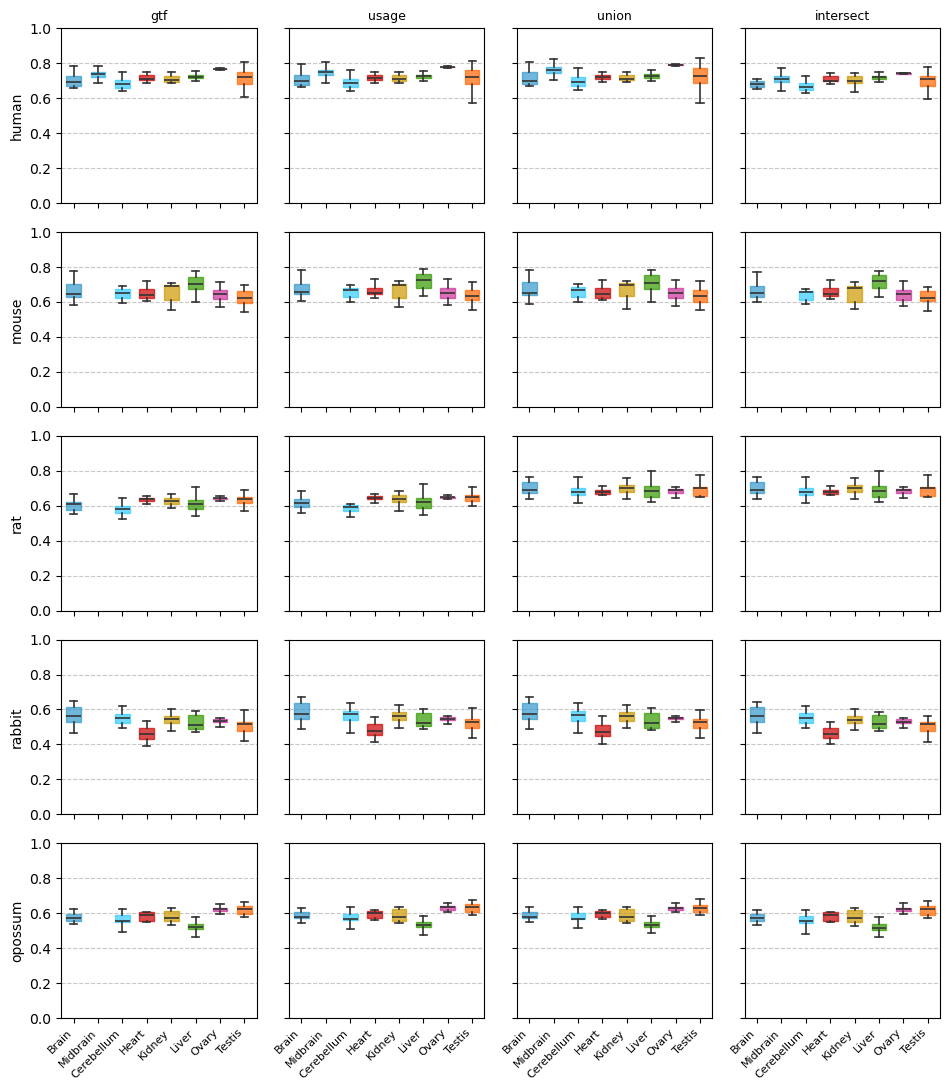

In [8]:
species_list = [s for s in SPECIES_ORDER if s in usage_results]
n_species = len(species_list)
n_subsets = len(subsets)

fig, axes = plt.subplots(
    n_species, n_subsets,
    figsize=(n_subsets * 2.4, n_species * 2.2),
    sharey=True, sharex=True
)

if n_species == 1 and n_subsets == 1:
    axes = np.array([[axes]])
elif n_species == 1:
    axes = axes[np.newaxis, :]
elif n_subsets == 1:
    axes = axes[:, np.newaxis]

x = np.arange(len(TISSUE_ORDER))

for row, sp in enumerate(species_list):
    for col, subset in enumerate(subsets):
        ax = axes[row, col]
        sp_data = usage_results.get(sp, {})
        usage_data = sp_data.get(subset) if sp_data else None
        tissue_data = usage_data.get("per_tissue", None) if usage_data else None

        if tissue_data:
            box_data = []
            positions = []
            colors = []

            for i, tissue in enumerate(TISSUE_ORDER):
                tp_dict = tissue_data.get(tissue, {}).get("timepoints", {})
                vals = [
                    tp_info.get("pearson_r", np.nan)
                    for tp_info in tp_dict.values()
                    if np.isfinite(tp_info.get("pearson_r", np.nan))
                ]

                if vals:
                    box_data.append(vals)
                    positions.append(i)
                    colors.append(TISSUE_COLORS.get(tissue, "#444444"))

            if box_data:
                bp = ax.boxplot(
                    box_data,
                    positions=positions,
                    widths=0.6,
                    patch_artist=True,
                    showfliers=False
                )

                for patch, color in zip(bp["boxes"], colors):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.7)
                    patch.set_edgecolor(color)

                for element in ["whiskers", "caps", "medians"]:
                    for artist in bp[element]:
                        artist.set_color("#333333")
                        artist.set_linewidth(1.2)

        ax.set_ylim(0, 1)
        ax.set_xlim(-0.5, len(TISSUE_ORDER) - 0.5)
        ax.grid(axis="y", linestyle="--", alpha=0.7)

        if row == 0:
            ax.set_title(subset, fontsize=9)
        if col == 0:
            ax.set_ylabel(sp, fontsize=10)

        ax.set_xticks(x)
        if row == n_species - 1:
            ax.set_xticklabels(TISSUE_ORDER, rotation=45, ha="right", fontsize=8)
        else:
            ax.set_xticklabels([])

plt.tight_layout()

plt.savefig(
    os.path.join(work_dir, model, "prediction_splice_usage_correlations_by_subsets.png"),
    dpi=300
)
plt.show()

## Evaluate usage predictions for sites with different developmental dynamics

Load usage predictions.

In [9]:
usage_results = {}

for sps in ["human", "mouse", "rat", "rabbit", "opossum"]:
    usage_results[sps] = {}

    # Load condition metadata: maps condition index -> "Tissue_Timepoint" label
    metadata_file = os.path.join(ann_data_dir, sci_sps[sps], "usage.json")
    if not os.path.exists(metadata_file):
        print(f"Metadata missing for {sps}: {metadata_file}")
        continue
    with open(metadata_file) as f:
        metadata = json.load(f)
    idx_to_label = {int(v): k for k, v in metadata.get("condition_labels", {}).items()}

    pd_key = 'union'
    usage_file = os.path.join(work_dir, model, f"preds_{pd_key}", sps, f"usage_{sps}.npz")
    if not os.path.exists(usage_file):
        print(f"  Usage file missing: {sps} / preds_{pd_key}")
        usage_results[sps][pd_key] = None
        continue

    data = np.load(usage_file)
    chr_pos    = data["chr_pos"]
    cond_ids   = data["cond_ids"]
    trues      = data["true"]
    preds      = data["pred"]

    # Split condition labels into Tissue and Timepoint
    tissues = []        
    timepoints = []
    for cond_id in cond_ids:
        tissue, timepoint = idx_to_label[cond_id].split("_")
        tissues.append(tissue)
        timepoints.append(timepoint)

    usage_results[sps] = {
        "chr_pos": chr_pos,
        "cond_ids": cond_ids,
        "tissues": tissues,
        "timepoints": timepoints,
        "trues": trues,
        "preds": preds,
        "idx_to_label": idx_to_label
    }

In [10]:
usage_results['human']['trues']

array([0.   , 0.   , 0.   , ..., 0.994, 0.995, 0.995],
      shape=(799744,), dtype=float32)

In [11]:
import copy

usage_results_filt = copy.deepcopy(usage_results)
for sps in usage_results_filt:
    if usage_results_filt[sps] is not None:
        mask = usage_results_filt[sps]['trues'] > 0
        for key in ['chr_pos', 'cond_ids', 'trues', 'preds']:
            usage_results_filt[sps][key] = usage_results_filt[sps][key][mask]
        for key in ['tissues', 'timepoints']:
            usage_results_filt[sps][key] = [usage_results_filt[sps][key][i] for i in range(len(usage_results_filt[sps][key])) if mask[i]]

usage_results_filt['human']['trues']


array([0.623, 0.952, 0.021, ..., 0.994, 0.995, 0.995],
      shape=(149385,), dtype=float32)

A site is classified as developmentally dynamic if the maximum amplitude of SSE change is greater than 0.2.

Dynamic sites are classified into four main developmental patterns:  
- Up: A progressive increase in SSE during development.
- Down: A progressive decrease in SSE during development.
- Up–Down: An initial increase in SSE followed by a decrease.
- Down–Up: An initial decrease in SSE followed by an increase.

To categorise these patterns, use a multi-step approach:  

- Use a cubic splines to approximate how SSE depends on developmental timepoint.
- Interpolate SSE values into 1,000 evenly distributed timepoints, and calculate the "SSE change" between each consecutive point.
- Derive four statistics for each site:
    - `up`: The sum of all positive SSE changes.
    - `down`: The absolute value of the sum of all negative SSE changes.
    - `up_timing`: The weighted average age of the positive changes (sum of positive changes multiplied by timepoint, then divided by the total `up` value).
    - `down_timing`: The weighted average age of the negative changes (absolute sum of negative changes multiplied by timepoint, then divided by the total `down` value).

Splice sites are assigned to one of the four classes based on the ratio of positive changes to the total change (`up`/(`up`+`down`)):  
- `down`: Assigned if the ratio is less than 0.3  
- `up`: Assigned if the ratio is greater than 0.7  
- `up–down`: For sites with a ratio between 0.3 and 0.7, if `up_timing`<`down_timing`  
- `down–up`: For sites with a ratio between 0.3 and 0.7, if `up_timing`>`down_timing`  

#### 1) Classify sites for each species and tissue

In [12]:
def classify_sites_by_true_usage_variance(
    usage_data,
    tissue,
    min_timepoints=5,
    aggfunc="mean",
    low_threshold=0.2,
    high_threshold=0.8,
    amplitude_threshold=0.2,
    direction_change_threshold=0.2,
    n_interp=1000,
):
    """
    Classify each unique site (chr_pos) in a tissue as:
      - dynamics_class: 'dynamic' or 'stable'
      - dynamics_subclass:
          stable -> 'high' / 'low' / 'median'
          dynamic -> 'up' / 'down' / 'up-down' / 'down-up'

    Rules:
      - stable if spline amplitude <= amplitude_threshold
      - stable if total directional change < direction_change_threshold
      - dynamic only if both amplitude and directional-change thresholds are met
    """
    
    from scipy.interpolate import CubicSpline
    
    required_keys = {"chr_pos", "tissues", "timepoints", "trues"}
    missing = required_keys - set(usage_data.keys())
    if missing:
        raise ValueError(f"usage_data is missing required keys: {sorted(missing)}")
    if not (0 <= low_threshold < high_threshold <= 1):
        raise ValueError("Expected 0 <= low_threshold < high_threshold <= 1")

    df = pd.DataFrame({
        "chr_pos": usage_data["chr_pos"],
        "tissue": usage_data["tissues"],
        "timepoint": usage_data["timepoints"],
        "true_usage": usage_data["trues"],
    })

    df = df[df["tissue"] == tissue].copy()
    if df.empty:
        return pd.DataFrame(columns=[
            "chr_pos", "tissue", "n_obs", "n_timepoints",
            "mean_true_usage", "true_usage_variance",
            "dynamics_class", "dynamics_subclass"
        ])

    df["timepoint_num"] = pd.to_numeric(df["timepoint"], errors="coerce")
    df = df.dropna(subset=["timepoint_num"]).copy()

    site_tp = (
        df.groupby(["chr_pos", "timepoint_num"], as_index=False)["true_usage"]
        .agg(aggfunc)
        .sort_values(["chr_pos", "timepoint_num"])
    )

    summary = (
        site_tp.groupby("chr_pos")["true_usage"]
        .agg(
            n_obs="size",
            n_timepoints="count",
            mean_true_usage="mean",
            true_usage_variance="var",
        )
        .reset_index()
    )

    summary["tissue"] = tissue
    summary = summary[summary["n_timepoints"] >= min_timepoints].copy()

    if summary.empty:
        summary["dynamics_class"] = pd.Series(dtype="object")
        summary["dynamics_subclass"] = pd.Series(dtype="object")
        return summary[[
            "chr_pos", "tissue", "n_obs", "n_timepoints",
            "mean_true_usage", "true_usage_variance",
            "dynamics_class", "dynamics_subclass"
        ]]

    summary["true_usage_variance"] = summary["true_usage_variance"].fillna(0.0)

    def _spline_change_stats(g):
        g = g.sort_values("timepoint_num")
        x = g["timepoint_num"].to_numpy(dtype=float)
        y = g["true_usage"].to_numpy(dtype=float)

        if x.size < 2 or np.unique(x).size < 2:
            return pd.Series({
                "sse_amplitude": 0.0,
                "up": 0.0,
                "down": 0.0,
                "total_change": 0.0,
                "up_timing": np.nan,
                "down_timing": np.nan,
                "ratio_up": np.nan,
                "dynamic_direction": "none",
            })

        spline = CubicSpline(x, y, bc_type="natural")
        x_new = np.linspace(x.min(), x.max(), n_interp)
        y_new = spline(x_new)

        dy = np.diff(y_new)
        t = x_new[1:]

        pos = dy > 0
        neg = dy < 0

        up = float(dy[pos].sum()) if np.any(pos) else 0.0
        down = float((-dy[neg]).sum()) if np.any(neg) else 0.0
        total = up + down

        up_timing = float((dy[pos] * t[pos]).sum() / up) if up > 0 else np.nan
        down_timing = float(((-dy[neg]) * t[neg]).sum() / down) if down > 0 else np.nan
        ratio_up = float(up / total) if total > 0 else np.nan
        amplitude = float(np.max(y_new) - np.min(y_new))

        if total < direction_change_threshold or np.isnan(ratio_up):
            direction = "none"
        elif ratio_up < 0.3:
            direction = "down"
        elif ratio_up > 0.7:
            direction = "up"
        else:
            if np.isnan(up_timing) or np.isnan(down_timing):
                direction = "none"
            else:
                direction = "up-down" if up_timing < down_timing else "down-up"

        return pd.Series({
            "sse_amplitude": amplitude,
            "up": up,
            "down": down,
            "total_change": total,
            "up_timing": up_timing,
            "down_timing": down_timing,
            "ratio_up": ratio_up,
            "dynamic_direction": direction,
        })

    trajectory = site_tp.groupby("chr_pos").apply(_spline_change_stats).reset_index()
    summary = summary.merge(trajectory, on="chr_pos", how="left")

    summary["dynamics_class"] = np.where(
        (summary["sse_amplitude"] > amplitude_threshold)
        & (summary["dynamic_direction"] != "none"),
        "dynamic",
        "stable",
    )

    summary["dynamics_subclass"] = np.where(
        summary["dynamics_class"] == "stable",
        np.where(
            summary["mean_true_usage"] > high_threshold,
            "high",
            np.where(summary["mean_true_usage"] < low_threshold, "low", "median"),
        ),
        summary["dynamic_direction"],
    )

    return summary[[
        "chr_pos", "tissue", "n_obs", "n_timepoints",
        "mean_true_usage", "true_usage_variance",
        "dynamics_class", "dynamics_subclass"
    ]]


In [13]:
from scipy.interpolate import make_interp_spline

dynamics_results = {}

for sps in SPECIES_ORDER:
    if sps not in usage_results_filt:
        continue
    sp_data = usage_results_filt[sps]
    if sp_data is None:
        continue

    tissues_available = sorted(set(sp_data['tissues']))
    dynamics_results[sps] = {}

    for tissue in tissues_available:
        df_cls = classify_sites_by_true_usage_variance(
            usage_data=sp_data,
            tissue=tissue,
        )
        dynamics_results[sps][tissue] = df_cls

/tmp/ipykernel_1453179/131859359.py:142: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trajectory = site_tp.groupby("chr_pos").apply(_spline_change_stats).reset_index()
/tmp/ipykernel_1453179/131859359.py:142: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trajectory = site_tp.groupby("chr_pos").apply(_spline_change_stats).reset_index()
/tmp/ipykernel_1453179/131859359.py:142: FutureWarning: DataFrameGroupBy.apply ope

#### 2) Inspect splice usage dynamics per species, tissue and subclass

In [14]:
class_rows = []
subclass_rows = []

for sps, tissue_map in dynamics_results.items():
    if not tissue_map:
        continue

    for tissue, df_cls in tissue_map.items():
        if df_cls is None or df_cls.empty:
            continue

        # 1) Count unique sites per dynamics class
        class_counts = (
            df_cls.groupby("dynamics_class", as_index=False)["chr_pos"]
            .nunique()
            .rename(columns={"chr_pos": "n_sites"})
        )
        class_counts["species"] = sps
        class_counts["tissue"] = tissue
        class_rows.append(class_counts)

        # 2) Count unique sites per dynamics subclass
        subclass_counts = (
            df_cls.groupby("dynamics_subclass", as_index=False)["chr_pos"]
            .nunique()
            .rename(columns={"chr_pos": "n_sites"})
        )
        subclass_counts["species"] = sps
        subclass_counts["tissue"] = tissue
        subclass_rows.append(subclass_counts)

class_counts_df = pd.concat(class_rows, ignore_index=True) if class_rows else pd.DataFrame(
    columns=["species", "tissue", "dynamics_class", "n_sites"]
)
subclass_counts_df = pd.concat(subclass_rows, ignore_index=True) if subclass_rows else pd.DataFrame(
    columns=["species", "tissue", "dynamics_subclass", "n_sites"]
)

# Keep a single table name if needed by downstream cells
counts_df = subclass_counts_df.copy()

if class_counts_df.empty and subclass_counts_df.empty:
    print("No classified sites found in dynamics_results.")
else:
    if not class_counts_df.empty:
        class_counts_df["tissue"] = pd.Categorical(class_counts_df["tissue"], categories=TISSUE_ORDER, ordered=True)
        class_counts_df["dynamics_class"] = pd.Categorical(
            class_counts_df["dynamics_class"], categories=["stable", "dynamic"], ordered=True
        )
        class_counts_df = class_counts_df.sort_values(["species", "tissue", "dynamics_class"]).reset_index(drop=True)
        display(class_counts_df)

    if not subclass_counts_df.empty:
        subclass_counts_df["tissue"] = pd.Categorical(subclass_counts_df["tissue"], categories=TISSUE_ORDER, ordered=True)
        subclass_counts_df["dynamics_subclass"] = pd.Categorical(
            subclass_counts_df["dynamics_subclass"],
            categories=["high", "median", "low", "up", "down", "up-down", "down-up", "none"],
            ordered=True
        )
        subclass_counts_df = subclass_counts_df.sort_values(
            ["species", "tissue", "dynamics_subclass"]
        ).reset_index(drop=True)
        display(subclass_counts_df)

,dynamics_class,n_sites,species,tissue
0,stable,2407,human,Brain
1,dynamic,527,human,Brain
2,stable,2635,human,Midbrain
3,dynamic,375,human,Midbrain
4,stable,863,human,Cerebellum
...,...,...,...,...
65,dynamic,136,rat,Liver
66,stable,2100,rat,Ovary
67,dynamic,124,rat,Ovary
68,stable,2686,rat,Testis


,dynamics_subclass,n_sites,species,tissue
0,high,1811,human,Brain
1,median,36,human,Brain
2,low,560,human,Brain
3,up,124,human,Brain
4,down,18,human,Brain
...,...,...,...,...
239,low,418,rat,Testis
240,up,13,rat,Testis
241,down,13,rat,Testis
242,up-down,60,rat,Testis


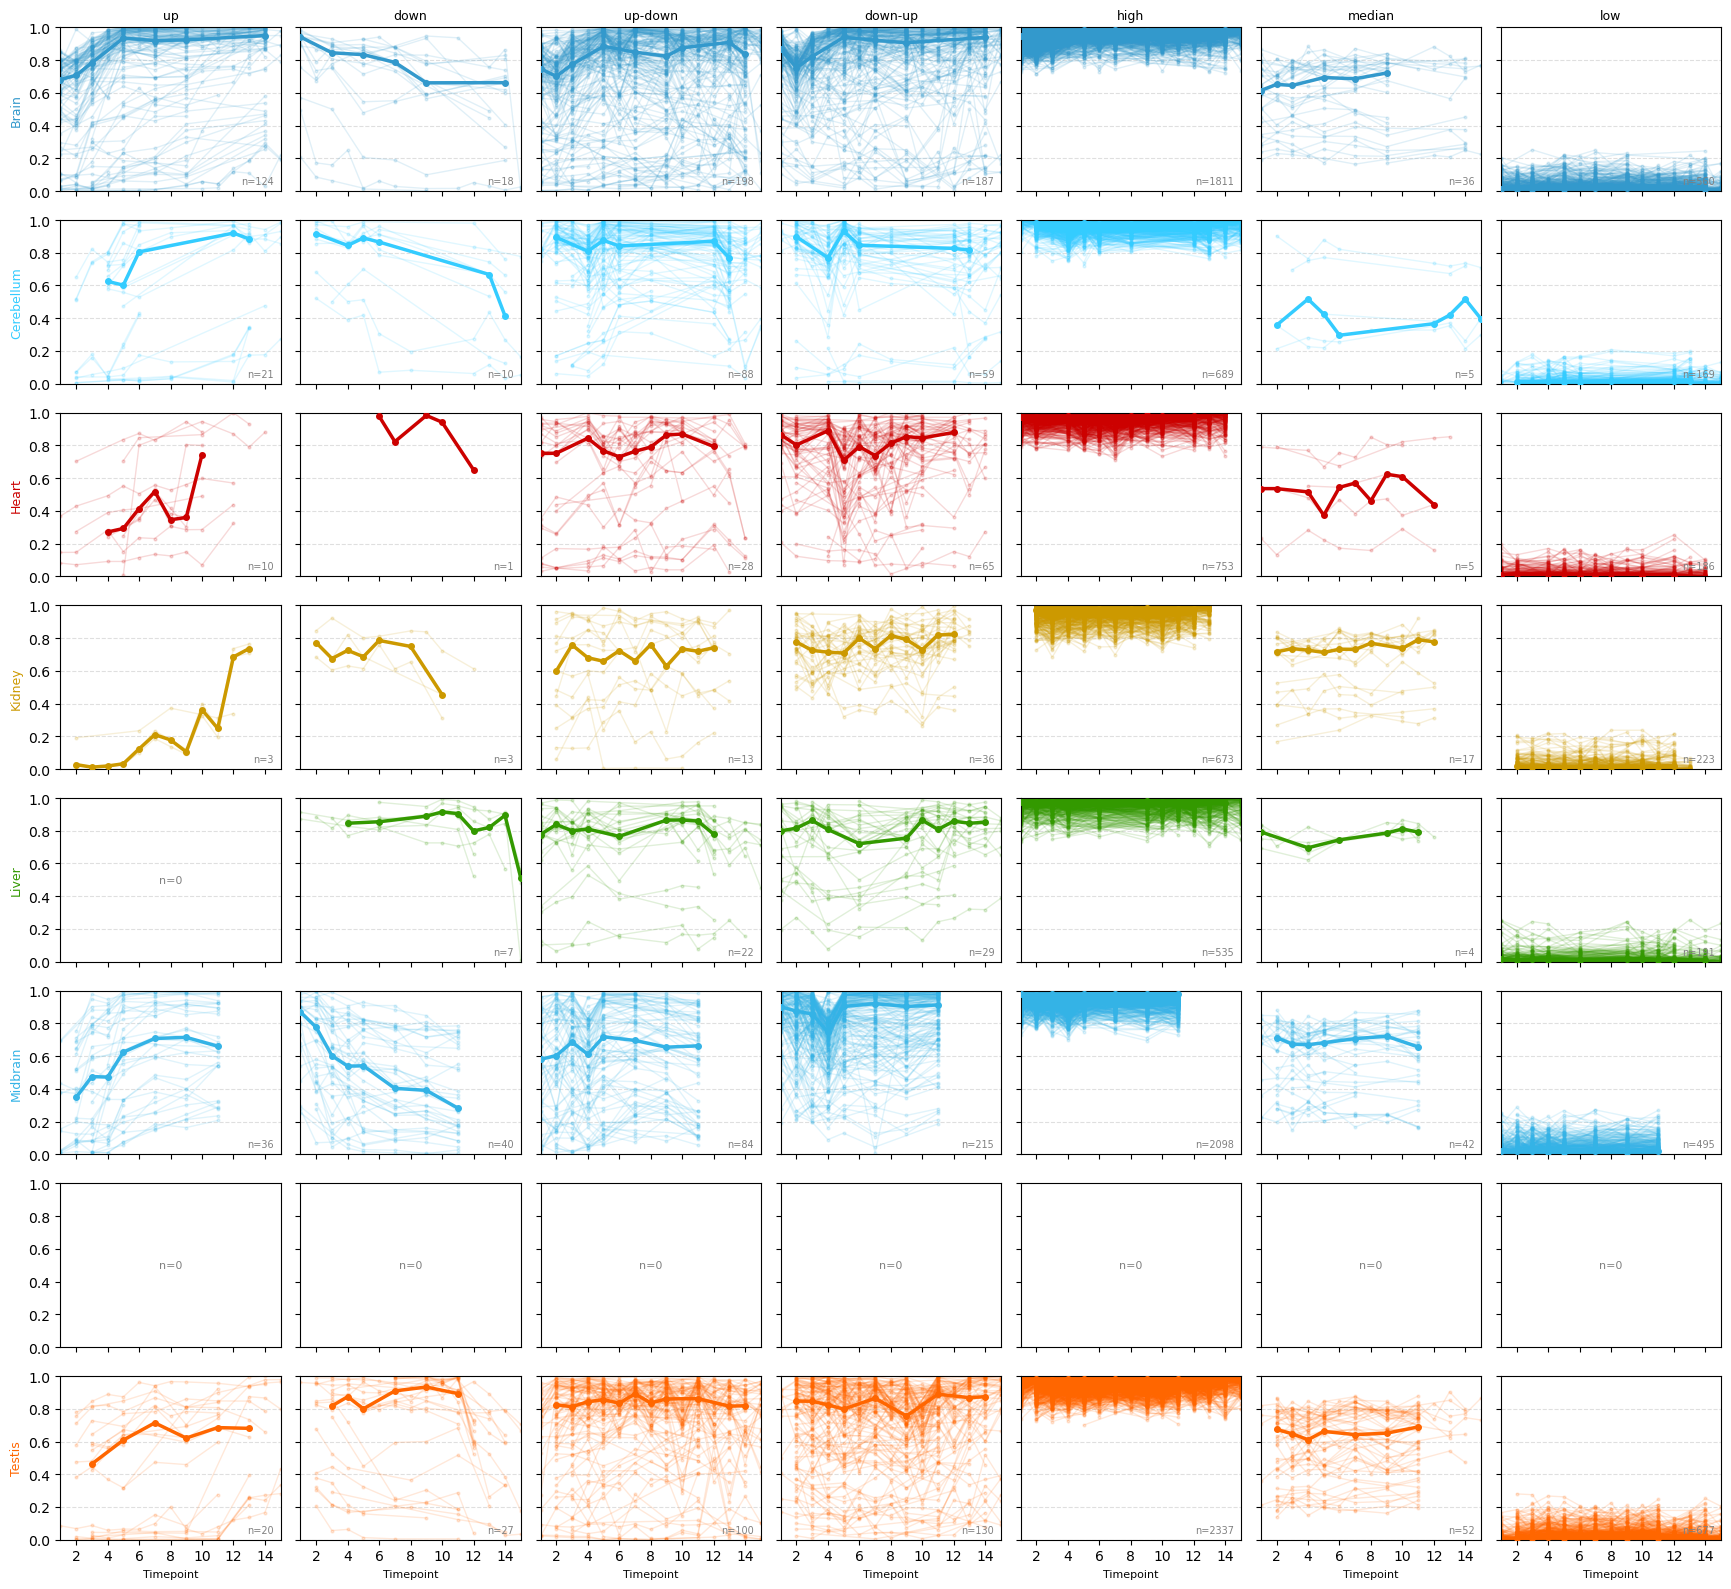

Saved: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_union_human_mouse_rat_rabbit_opossum/dynamics_true_usage_human.png


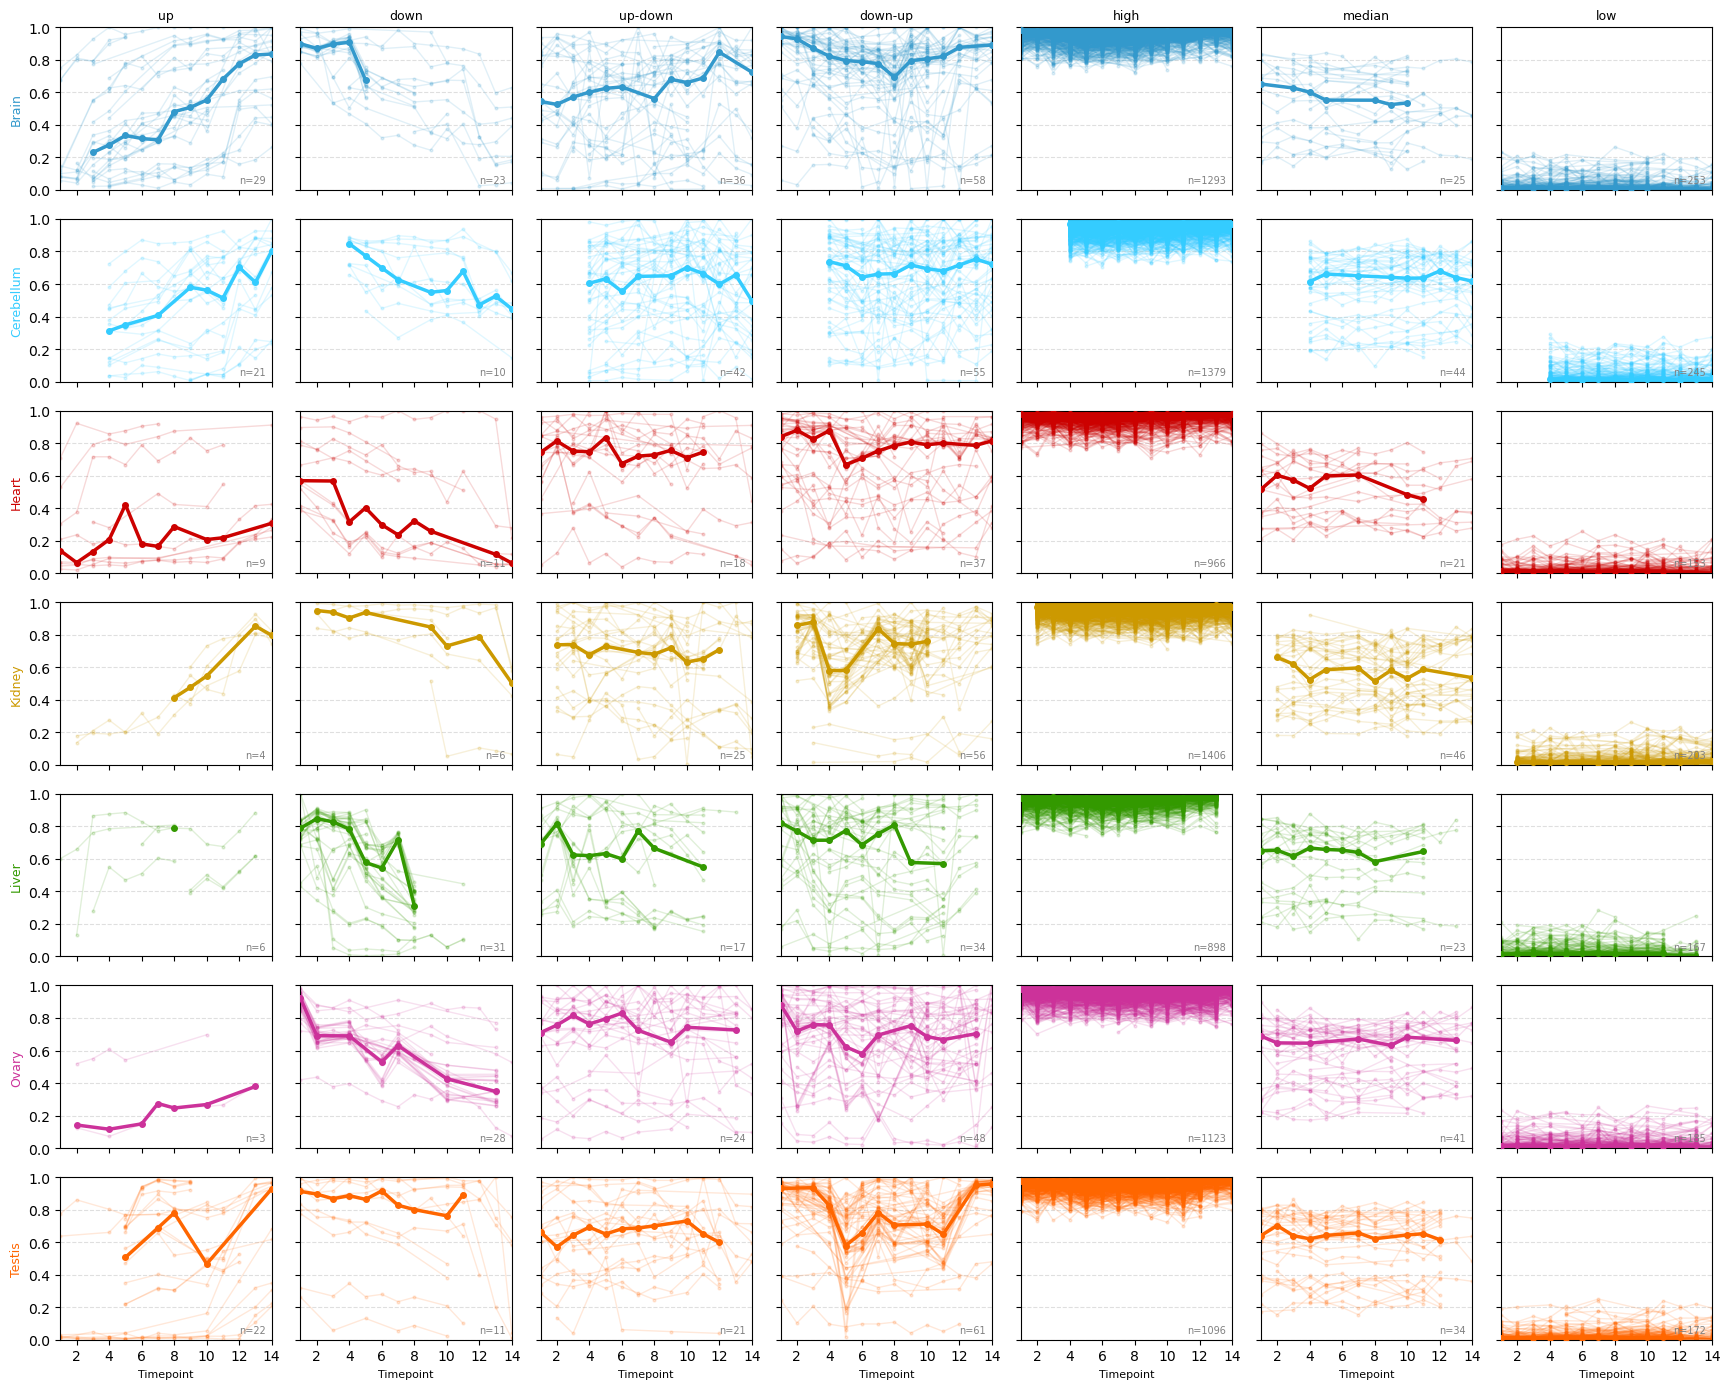

Saved: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_union_human_mouse_rat_rabbit_opossum/dynamics_true_usage_mouse.png


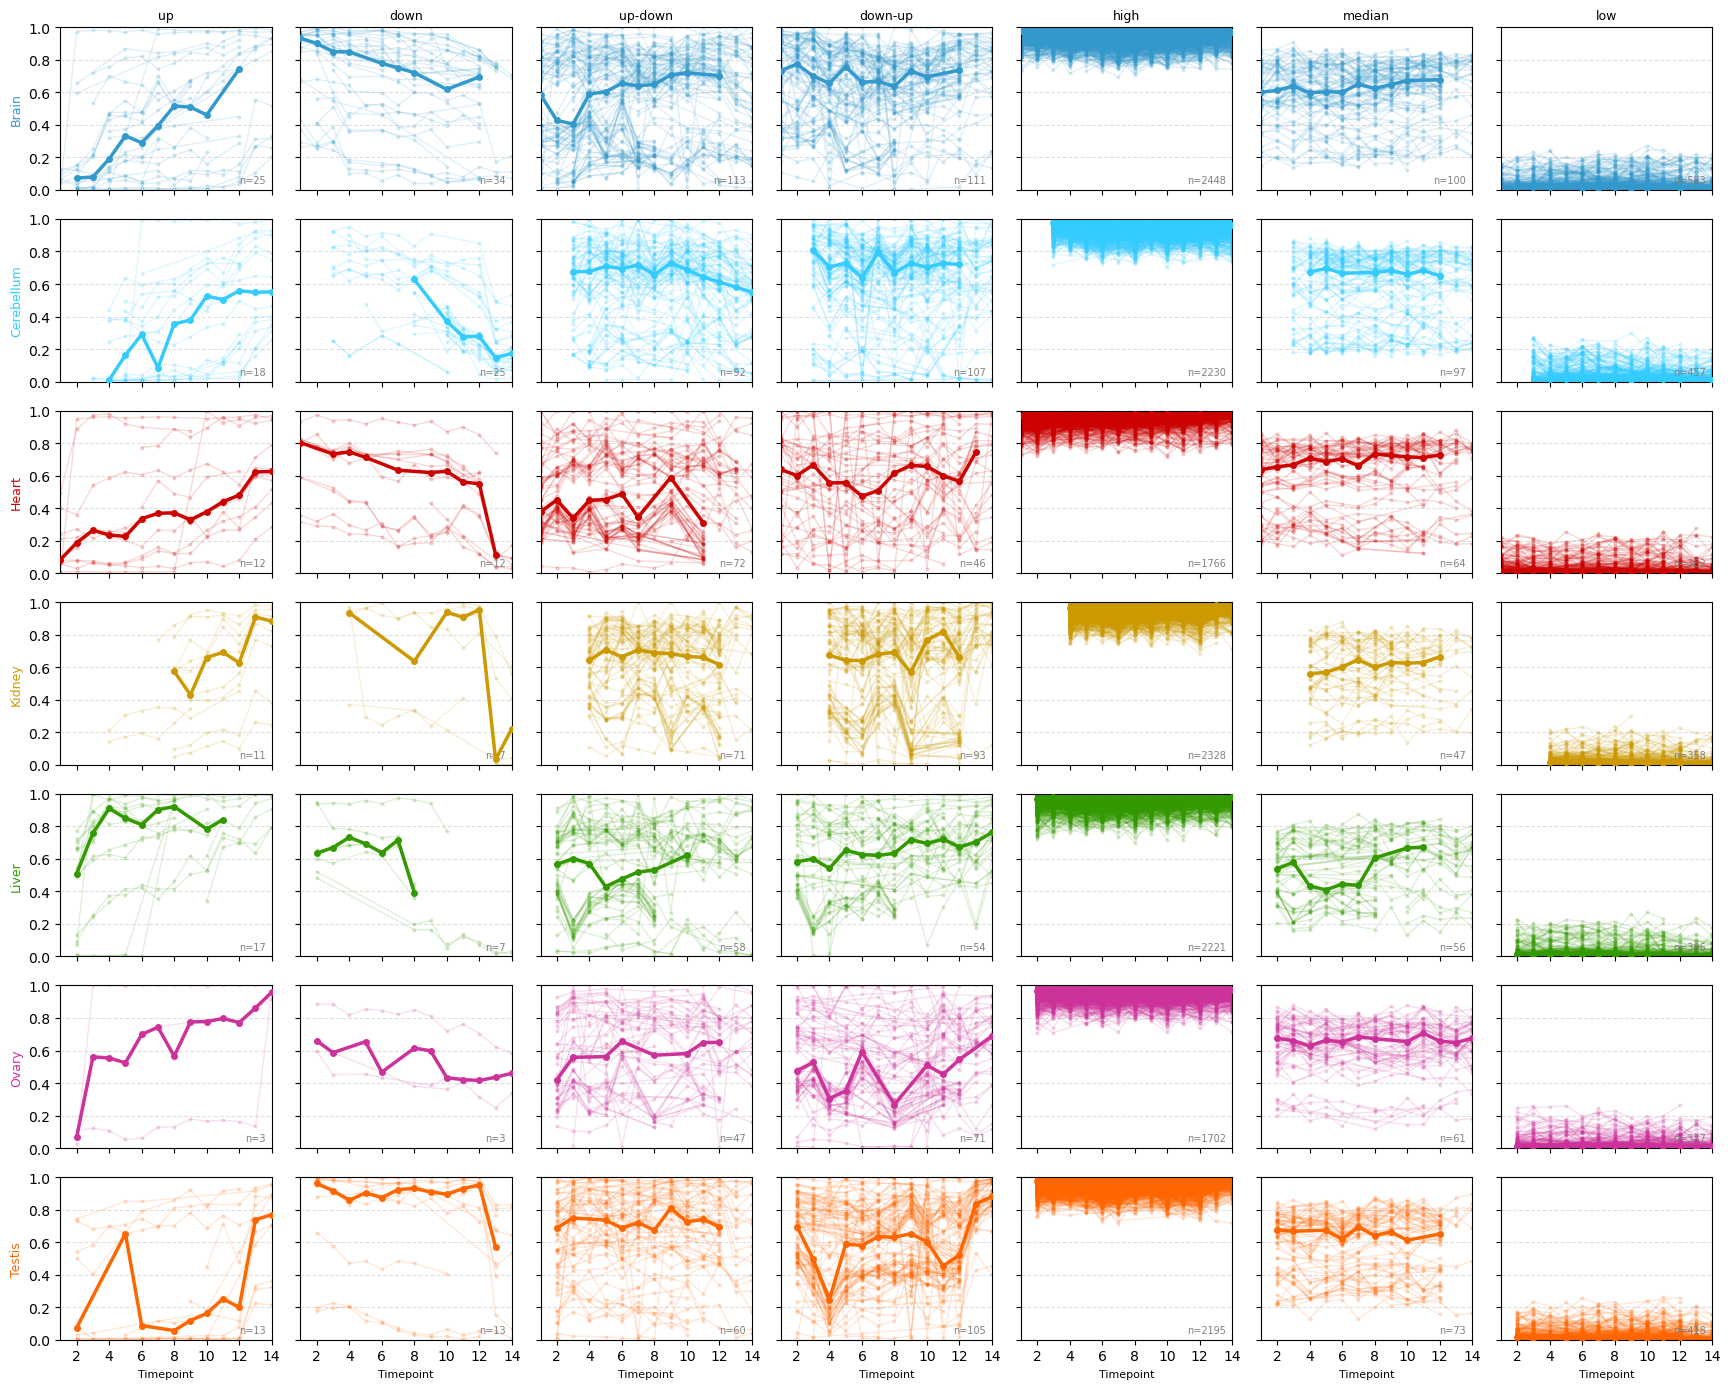

Saved: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_union_human_mouse_rat_rabbit_opossum/dynamics_true_usage_rat.png


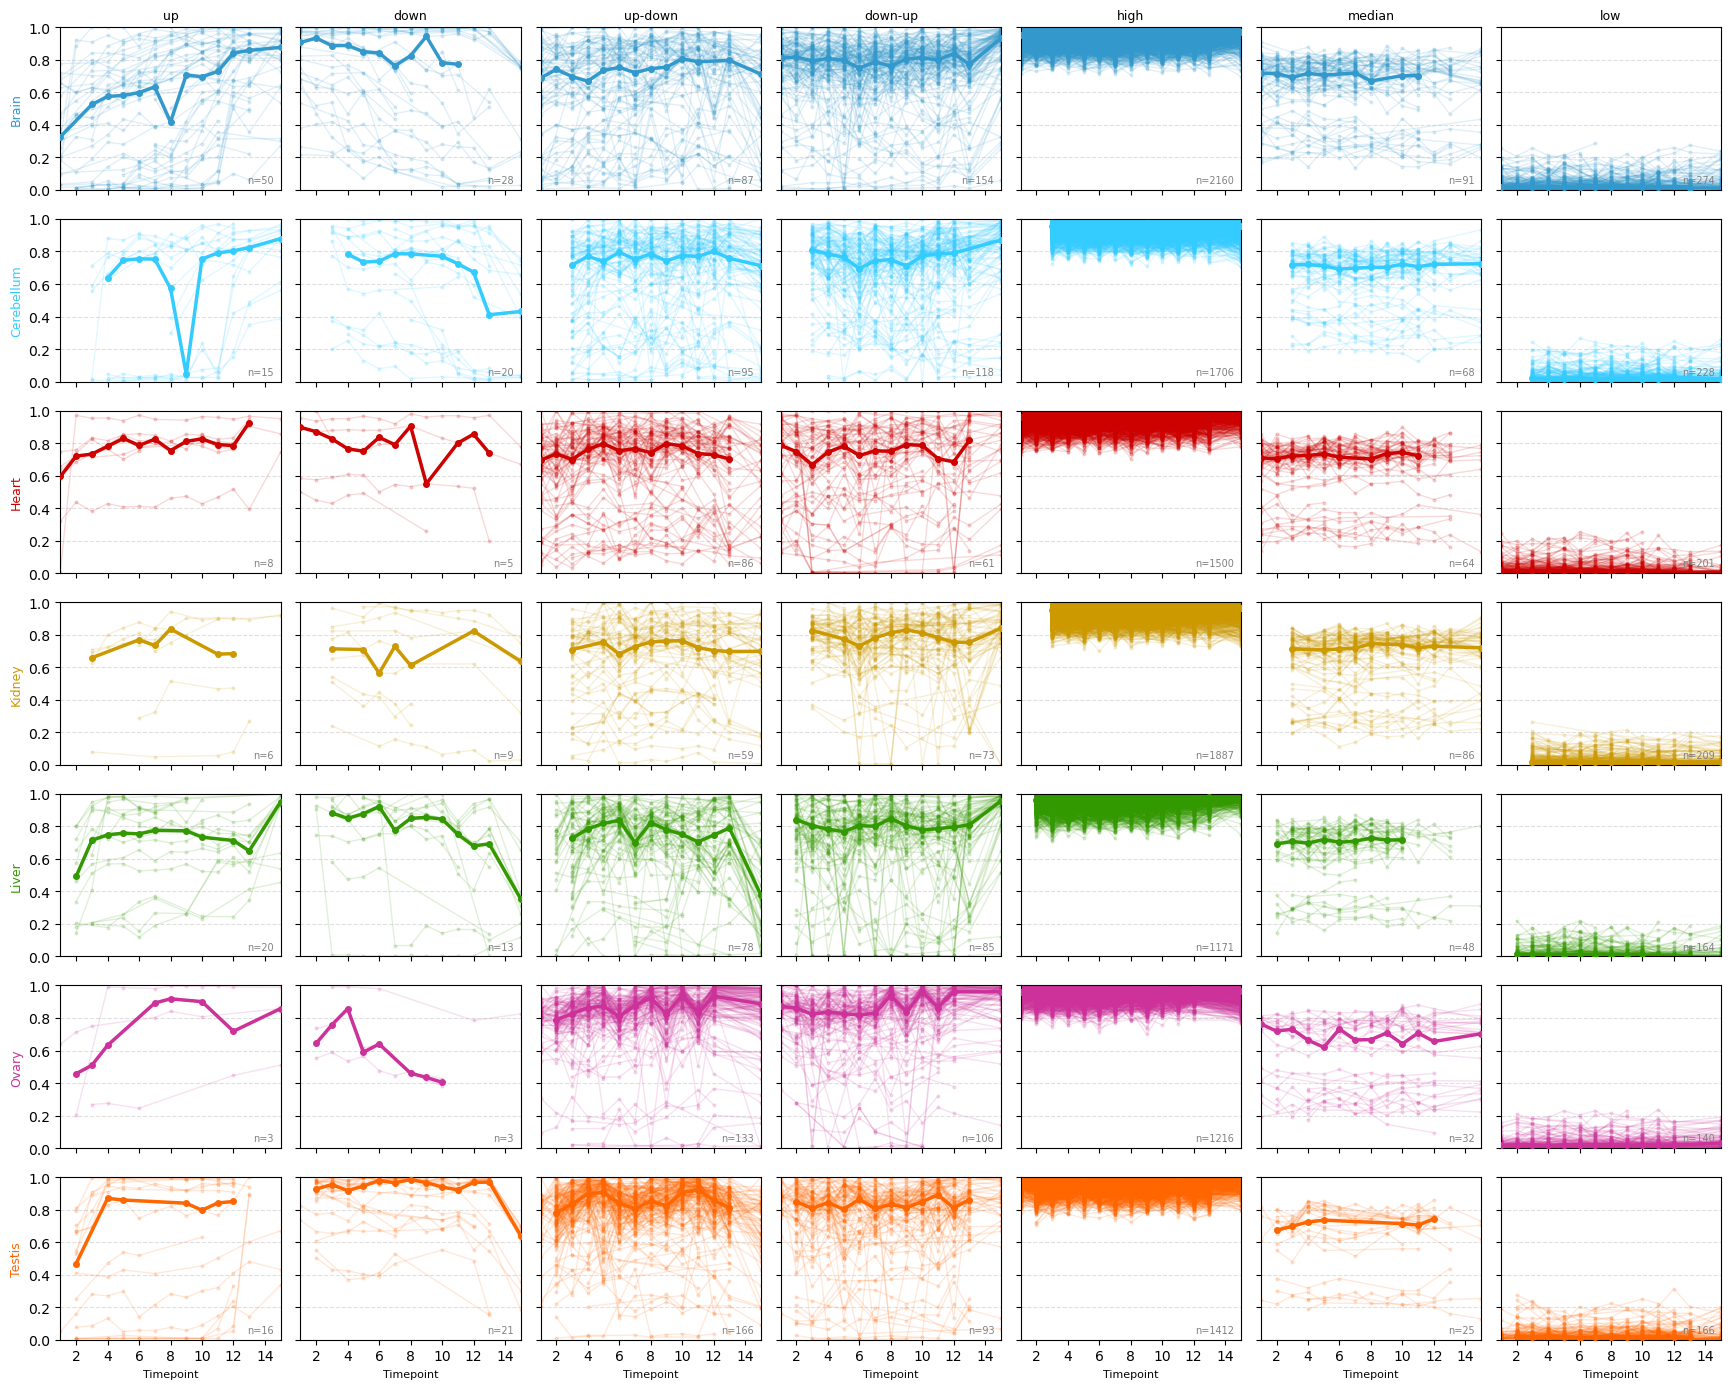

Saved: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_union_human_mouse_rat_rabbit_opossum/dynamics_true_usage_rabbit.png


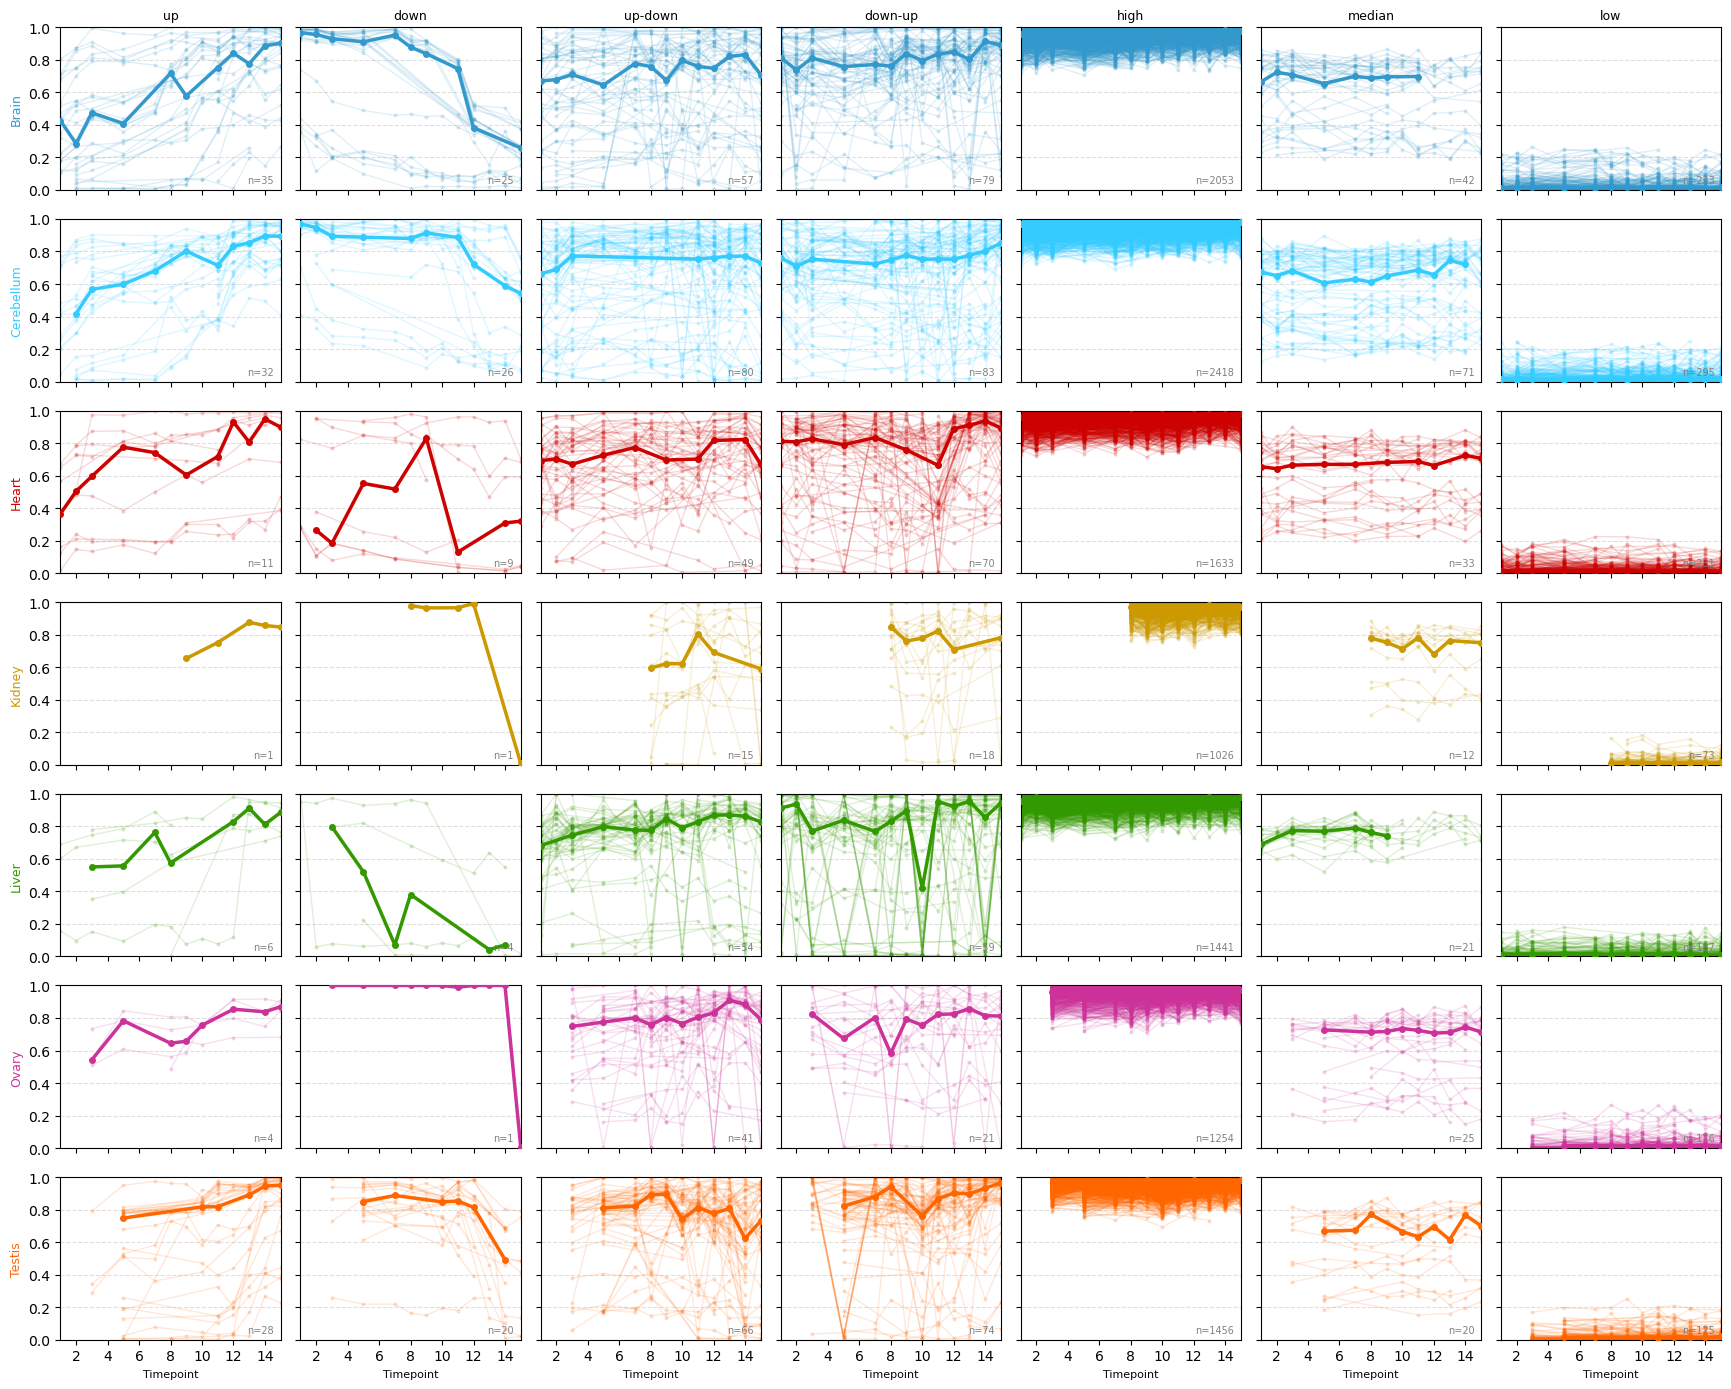

Saved: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_union_human_mouse_rat_rabbit_opossum/dynamics_true_usage_opossum.png


In [15]:
# Toggle: False = raw lines (default), True = cubic spline smoothing
USE_SPLINES = False

# Helper: cubic spline plotting (falls back to straight line if not enough points)
def plot_cubic_spline(ax, x, y, color, linewidth, alpha=1.0, zorder=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # unique/sorted x for spline stability
    x_u, idx = np.unique(x, return_index=True)
    y_u = y[idx]
    order = np.argsort(x_u)
    x_u, y_u = x_u[order], y_u[order]

    if len(x_u) >= 4:  # cubic needs at least 4 points
        x_smooth = np.linspace(x_u.min(), x_u.max(), 200)
        y_smooth = make_interp_spline(x_u, y_u, k=3)(x_smooth)
        y_smooth = np.clip(y_smooth, 0, 1)
        ax.plot(x_smooth, y_smooth, color=color, linewidth=linewidth, alpha=alpha, zorder=zorder)
    else:
        ax.plot(x_u, y_u, color=color, linewidth=linewidth, alpha=alpha, zorder=zorder)

def plot_curve(ax, x, y, color, linewidth, alpha=1.0, zorder=None, use_splines=False):
    if use_splines:
        plot_cubic_spline(ax, x, y, color=color, linewidth=linewidth, alpha=alpha, zorder=zorder)
    else:
        ax.plot(x, y, color=color, linewidth=linewidth, alpha=alpha, zorder=zorder)

SUBCLASS_ORDER = ['up', 'down', 'up-down', 'down-up', 'high', 'median', 'low']

for sps in SPECIES_ORDER:
    if sps not in dynamics_results:
        continue

    tissues_available = sorted(dynamics_results[sps].keys())
    if not tissues_available:
        continue

    sp_data = usage_results_filt[sps]
    df_raw = pd.DataFrame({
        'chr_pos': sp_data['chr_pos'],
        'tissue': sp_data['tissues'],
        'timepoint': pd.to_numeric(sp_data['timepoints'], errors='coerce'),
        'true_usage': sp_data['trues'].astype(float),
    }).dropna(subset=['timepoint'])
    df_raw['timepoint'] = df_raw['timepoint'].astype(int)

    if df_raw.empty:
        continue

    tp_min = int(df_raw['timepoint'].min())
    tp_max = int(df_raw['timepoint'].max())
    x_ticks = np.arange(tp_min + 1, tp_max + 1, 2, dtype=int)

    n_tissues = len(tissues_available)
    n_subclasses = len(SUBCLASS_ORDER)

    fig, axes = plt.subplots(
        n_tissues, n_subclasses,
        figsize=(n_subclasses * 2.5, n_tissues * 2),
        sharex=True,
        sharey=True,
    )
    if n_tissues == 1:
        axes = axes[np.newaxis, :]
    if n_subclasses == 1:
        axes = axes[:, np.newaxis]

    for row, tissue in enumerate(tissues_available):
        df_cls = dynamics_results[sps][tissue]
        tissue_color = TISSUE_COLORS.get(tissue, '#444444')

        if df_cls.empty:
            for col in range(n_subclasses):
                ax = axes[row, col]
                ax.text(0.5, 0.5, 'n=0', ha='center', va='center',
                        transform=ax.transAxes, fontsize=8, color='gray')
            continue

        df_merged = df_raw[df_raw['tissue'] == tissue].merge(
            df_cls[['chr_pos', 'dynamics_subclass']], on='chr_pos', how='inner'
        )

        for col, subclass in enumerate(SUBCLASS_ORDER):
            ax = axes[row, col]
            df_sub = df_merged[df_merged['dynamics_subclass'] == subclass]
            n_sites = df_sub['chr_pos'].nunique()

            if df_sub.empty:
                ax.text(0.5, 0.5, 'n=0', ha='center', va='center',
                        transform=ax.transAxes, fontsize=8, color='gray')
            else:
                site_tp_mean = (
                    df_sub.groupby(['chr_pos', 'timepoint'])['true_usage']
                    .mean()
                    .reset_index()
                )

                # Individual site curves + points
                for site in site_tp_mean['chr_pos'].unique():
                    site_data = site_tp_mean[site_tp_mean['chr_pos'] == site].sort_values('timepoint')
                    plot_curve(
                        ax=ax,
                        x=site_data['timepoint'].values,
                        y=site_data['true_usage'].values,
                        color=tissue_color,
                        linewidth=1,
                        alpha=0.15,
                        use_splines=USE_SPLINES,
                    )
                    ax.plot(
                        site_data['timepoint'], site_data['true_usage'],
                        linestyle='None', marker='o', markersize=2,
                        color=tissue_color, alpha=0.15
                    )

                # Median curve + points (only for timepoints with majority coverage)
                n_total_sites = site_tp_mean['chr_pos'].nunique()
                tp_coverage = (
                    site_tp_mean.groupby('timepoint')['chr_pos']
                    .nunique()
                    .reset_index(name='n_sites_with_measurement')
                )
                valid_tps = tp_coverage.loc[
                    tp_coverage['n_sites_with_measurement'] > (n_total_sites / 2),
                    'timepoint'
                ]

                tp_stats = (
                    site_tp_mean[site_tp_mean['timepoint'].isin(valid_tps)]
                    .groupby('timepoint')['true_usage']
                    .median()
                    .reset_index()
                    .sort_values('timepoint')
                )
                plot_curve(
                    ax=ax,
                    x=tp_stats['timepoint'].values,
                    y=tp_stats['true_usage'].values,
                    color=tissue_color,
                    linewidth=2.5,
                    alpha=1.0,
                    zorder=10,
                    use_splines=USE_SPLINES,
                )
                ax.plot(
                    tp_stats['timepoint'], tp_stats['true_usage'],
                    linestyle='None', marker='o', markersize=4,
                    color=tissue_color, zorder=11, label='Median'
                )

                ax.text(
                    0.97, 0.03, f'n={n_sites}',
                    ha='right', va='bottom', transform=ax.transAxes,
                    fontsize=7, color='gray'
                )

            ax.grid(axis='y', linestyle='--', alpha=0.4)
            if row == 0:
                ax.set_title(subclass, fontsize=9)
            if col == 0:
                ax.set_ylabel(tissue, fontsize=9, color=tissue_color)
            if row == n_tissues - 1:
                ax.set_xlabel('Timepoint', fontsize=8)

    for ax in axes.flat:
        ax.set_xlim(tp_min, tp_max)
        ax.set_xticks(x_ticks)
        ax.set_ylim(0, 1)

    plt.tight_layout()

    out_path = os.path.join(work_dir, model, f"dynamics_true_usage_{sps}.png")
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out_path}")

#### 3) Evaluate usage prediction per species, tissue and subclass

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Build a long dataframe with true/pred usage + dynamics subclass labels
rows = []

for sps in SPECIES_ORDER:
    if sps not in usage_results or sps not in dynamics_results:
        continue
    sp_data = usage_results[sps]
    if sp_data is None:
        continue

    df_usage = pd.DataFrame({
        "species": sps,
        "chr_pos": np.asarray(sp_data["chr_pos"]).astype(str),
        "tissue": np.asarray(sp_data["tissues"]).astype(str),
        "timepoint": pd.to_numeric(np.asarray(sp_data["timepoints"]), errors="coerce"),
        "true_usage": np.asarray(sp_data["trues"], dtype=float),
        "pred_usage": np.asarray(sp_data["preds"], dtype=float),
    }).dropna(subset=["timepoint"])

    cls_frames = []
    for tissue, df_cls_t in dynamics_results[sps].items():
        if df_cls_t is None or df_cls_t.empty:
            continue
        cls_frames.append(
            df_cls_t[["chr_pos", "tissue", "dynamics_class", "dynamics_subclass"]].drop_duplicates()
        )

    if not cls_frames:
        continue

    df_cls_sp = pd.concat(cls_frames, ignore_index=True).drop_duplicates(["chr_pos", "tissue"])
    df_sp = df_usage.merge(df_cls_sp, on=["chr_pos", "tissue"], how="inner")
    rows.append(df_sp)

df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(
    columns=[
        "species", "chr_pos", "tissue", "timepoint",
        "true_usage", "pred_usage", "dynamics_class", "dynamics_subclass"
    ]
)

def _pearson_safe(g):
    x = g["true_usage"].to_numpy(dtype=float)
    y = g["pred_usage"].to_numpy(dtype=float)
    if len(x) < 2 or np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def _mae_safe(g):
    x = g["true_usage"].to_numpy(dtype=float)
    y = g["pred_usage"].to_numpy(dtype=float)
    return mean_absolute_error(x, y) if len(x) > 0 else np.nan

def _rmse_safe(g):
    x = g["true_usage"].to_numpy(dtype=float)
    y = g["pred_usage"].to_numpy(dtype=float)
    return np.sqrt(mean_squared_error(x, y)) if len(x) > 0 else np.nan

corr_df = (
    df.groupby(["species", "tissue", "dynamics_subclass"], as_index=False)
      .apply(lambda g: pd.Series({
          "n_obs": len(g),
          "n_sites": g["chr_pos"].nunique(),
          "pearson_r": _pearson_safe(g),
          "mae": _mae_safe(g),
          "rmse": _rmse_safe(g),
      }))
      .reset_index(drop=True)
)

corr_df["r_squared"] = corr_df["pearson_r"] ** 2
corr_df["n_obs"] = corr_df["n_obs"].astype(int)
corr_df["n_sites"] = corr_df["n_sites"].astype(int)
corr_df = corr_df.sort_values(["species", "tissue", "dynamics_subclass"]).reset_index(drop=True)

display(corr_df)

/tmp/ipykernel_1453179/4165567818.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,species,tissue,dynamics_subclass,n_obs,n_sites,pearson_r,mae,rmse,r_squared
0,human,Brain,down,270,18,0.730937,0.173828,0.255525,0.534268
1,human,Brain,down-up,2820,187,0.715298,0.210531,0.308687,0.511652
2,human,Brain,high,27255,1811,0.743015,0.229717,0.333027,0.552071
3,human,Brain,low,8625,560,0.234245,0.026292,0.077146,0.054871
4,human,Brain,median,540,36,0.504950,0.192586,0.296737,0.254975
...,...,...,...,...,...,...,...,...,...
239,rat,Testis,high,31291,2195,0.445469,0.381679,0.457394,0.198443
240,rat,Testis,low,5525,418,0.258114,0.043909,0.101420,0.066623
241,rat,Testis,median,1105,73,0.273582,0.289953,0.355055,0.074847
242,rat,Testis,up,169,13,0.456819,0.218585,0.324273,0.208683


/tmp/ipykernel_1453179/2433182131.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby(["dynamics_subclass", "species"], as_index=False)["n_sites"]


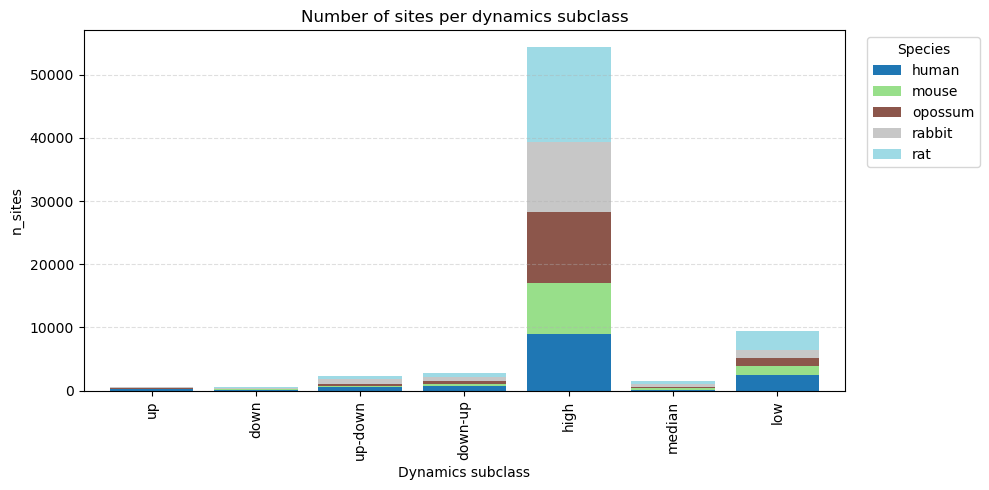

In [23]:
# Plot total n_sites per dynamics subclass (stacked by species)

if "subclass_counts_df" in globals() and not subclass_counts_df.empty:
    plot_df = subclass_counts_df.copy()
elif "corr_df" in globals() and not corr_df.empty:
    plot_df = corr_df[["species", "dynamics_subclass", "n_sites"]].copy()
else:
    raise ValueError("No suitable dataframe found (expected subclass_counts_df or corr_df).")

summary_df = (
    plot_df.groupby(["dynamics_subclass", "species"], as_index=False)["n_sites"]
    .sum()
)

subclass_order = [s for s in SUBCLASS_ORDER if s in summary_df["dynamics_subclass"].unique()]
species_order = [s for s in SPECIES_ORDER if s in summary_df["species"].unique()]

pivot_df = (
    summary_df.pivot(index="dynamics_subclass", columns="species", values="n_sites")
    .reindex(subclass_order)
    .fillna(0)
)

ax = pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    width=0.8,
    colormap="tab20"
)

ax.set_title("Number of sites per dynamics subclass")
ax.set_xlabel("Dynamics subclass")
ax.set_ylabel("n_sites")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Species", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

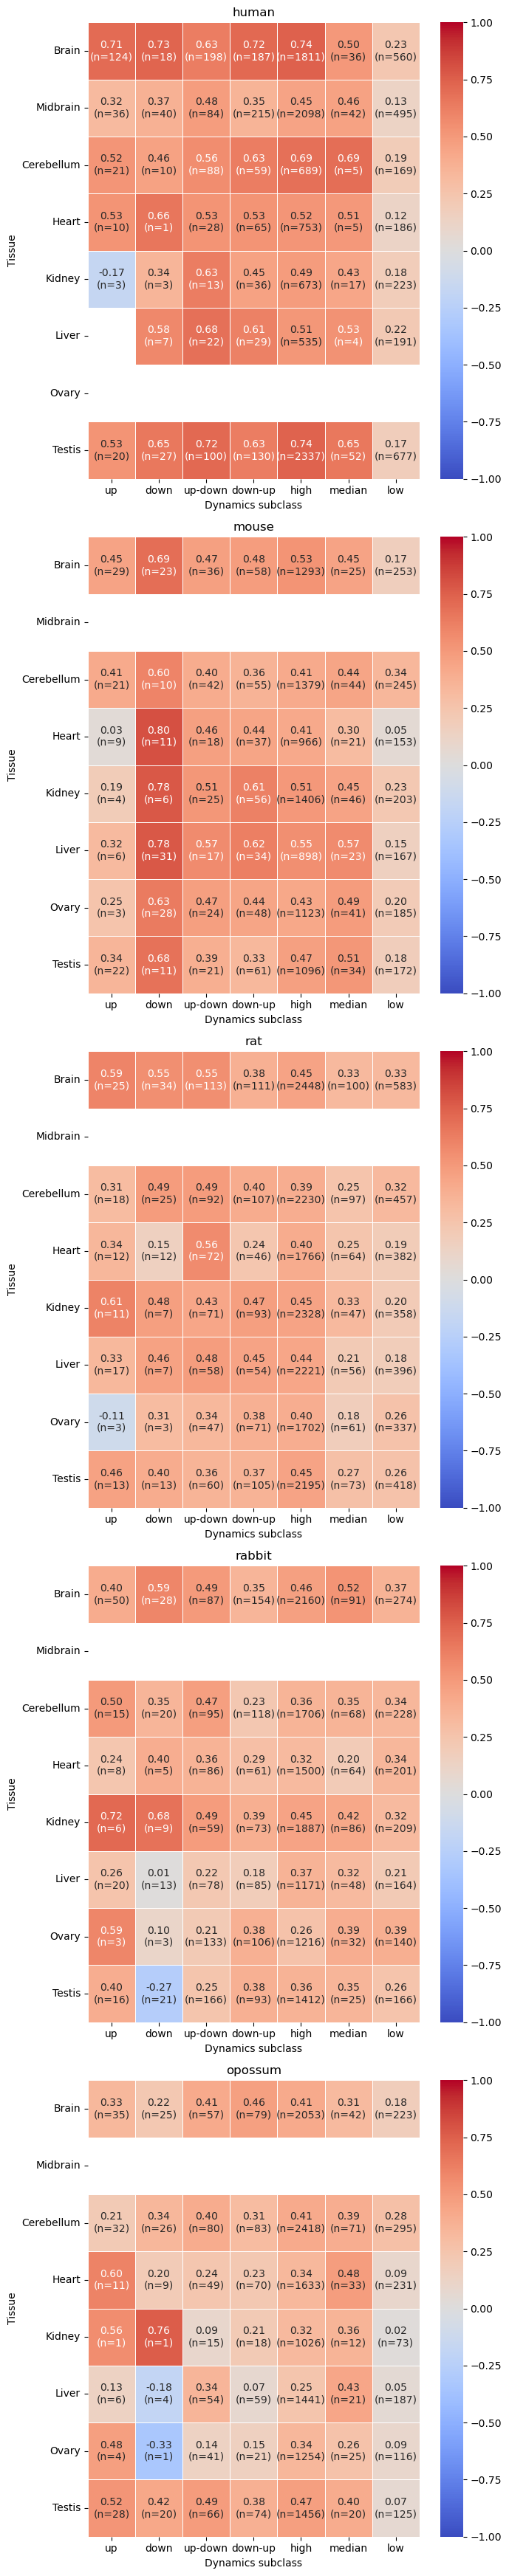

In [17]:
species_plot = [s for s in SPECIES_ORDER if s in corr_df["species"].unique()]
subclass_plot = [s for s in SUBCLASS_ORDER if s in corr_df["dynamics_subclass"].unique()]
tissue_plot = [t for t in TISSUE_ORDER if t in corr_df["tissue"].unique()]

fig, axes = plt.subplots(
    len(species_plot), 1,
    figsize=(max(len(subclass_plot), 6), max(7 * len(species_plot), 6)),
    sharex=False
)

if len(species_plot) == 1:
    axes = [axes]

for i, (ax, sp) in enumerate(zip(axes, species_plot)):
    df_sp = corr_df[corr_df["species"] == sp]

    mat_r = (
        df_sp.pivot_table(
            index="tissue",
            columns="dynamics_subclass",
            values="pearson_r",
            aggfunc="mean"
        )
        .reindex(index=tissue_plot, columns=subclass_plot)
    )

    mat_n = (
        df_sp.pivot_table(
            index="tissue",
            columns="dynamics_subclass",
            values="n_sites",
            aggfunc="sum"
        )
        .reindex(index=tissue_plot, columns=subclass_plot)
    )

    annot = mat_r.copy().astype(object)
    for r in mat_r.index:
        for c in mat_r.columns:
            rv = mat_r.loc[r, c]
            nv = mat_n.loc[r, c]
            if pd.isna(rv):
                annot.loc[r, c] = ""
            else:
                n_txt = "NA" if pd.isna(nv) else f"{int(nv)}"
                annot.loc[r, c] = f"{rv:.2f}\n(n={n_txt})"

    sns.heatmap(
        mat_r,
        ax=ax,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        annot=annot,
        fmt="",
        linewidths=0.4,
        linecolor="white"
    )

    ax.set_title(sp)
    ax.set_xlabel("Dynamics subclass")
    ax.set_ylabel("Tissue")

plt.tight_layout()
plt.show()

### Plot site dynamics by developmental timepoint

In [18]:
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

def plot_splice_site_dynamics(
    usage_results,
    site_coords,
    metric='both',  # 'both' plots true (solid) + pred (dotted)
    species_order=None,
    tissue_order=None,
    tissue_colors=None,
    figsize=None,
    title=None,
    jitter=0.0,
    verbose=False,
):
    import matplotlib.pyplot as plt

    if isinstance(site_coords, str):
        site_coords = [site_coords]

    if tissue_order is None:
        tissue_order = TISSUE_ORDER
    if tissue_colors is None:
        tissue_colors = TISSUE_COLORS
    if species_order is None:
        species_order = list(usage_results.keys())

    # Build/cache per-species dataframe from usage_results
    sp_df_cache = {}
    for sp, sp_data in usage_results.items():
        chr_pos = np.asarray(sp_data['chr_pos']).astype(str)
        cond_ids = np.asarray(sp_data['cond_ids'])
        tissues = np.asarray(sp_data['tissues'])
        timepoints = np.asarray(sp_data['timepoints'])
        trues = np.asarray(sp_data['trues'], dtype=float)
        preds = np.asarray(sp_data['preds'], dtype=float)

        split = np.char.partition(chr_pos, ':')
        chrom = split[:, 0]
        pos = split[:, 2].astype(int)

        df_sp = pd.DataFrame({
            'Species': sp,
            'Chromosome': chrom,
            'Position': pos,
            'condition': cond_ids,
            'tissue': tissues,
            'timepoint': pd.to_numeric(timepoints, errors='coerce'),
            'true': trues,
            'pred': preds,
        }).dropna(subset=['timepoint'])
        df_sp['timepoint'] = df_sp['timepoint'].astype(int)
        df_sp['SSE'] = (df_sp['pred'] - df_sp['true']) ** 2
        df_sp['abs_error'] = np.abs(df_sp['pred'] - df_sp['true'])

        sp_df_cache[sp] = df_sp

    # Parse coordinates
    site_filters = []
    for coord in site_coords:
        parts = coord.strip().split()
        if len(parts) != 2:
            print(f"Warning: Invalid coordinate format '{coord}'. Expected 'species chrom:pos' or 'species chrom:start-end'")
            continue

        species = parts[0].lower()
        if species not in sp_df_cache:
            print(f"Warning: Species '{species}' not found in usage_results")
            continue

        cparts = parts[1].split(':')
        if len(cparts) < 2:
            print(f"Warning: Invalid coordinate '{coord}'")
            continue

        chrom = cparts[0]
        pos_or_range = cparts[1]

        if '-' in pos_or_range:
            try:
                start, end = map(int, pos_or_range.split('-'))
            except ValueError:
                print(f"Warning: Invalid range in '{coord}'")
                continue

            df_sp = sp_df_cache[species]
            mask = (
                (df_sp['Chromosome'] == str(chrom)) &
                (df_sp['Position'] >= start) &
                (df_sp['Position'] <= end)
            )
            positions = sorted(df_sp.loc[mask, 'Position'].unique())
            if len(positions) == 0:
                print(f"Warning: No sites found in range {coord}")
                continue

            for p in positions:
                site_filters.append((species, str(chrom), int(p)))
            print(f"Found {len(positions)} sites in {coord}")
        else:
            try:
                pos = int(pos_or_range)
            except ValueError:
                print(f"Warning: Invalid position in '{coord}'")
                continue
            site_filters.append((species, str(chrom), pos))

    if not site_filters:
        print("No valid site coordinates provided")
        return None

    sp_rank = {sp: i for i, sp in enumerate(species_order)}
    site_filters = sorted(site_filters, key=lambda x: (sp_rank.get(x[0], 10**9), x[1], x[2]))

    n_sites = len(site_filters)
    n_cols = min(3, n_sites)
    n_rows = (n_sites + n_cols - 1) // n_cols

    if figsize is None:
        figsize = (n_cols * 5, n_rows * 4)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    all_tissues_found = set()

    valid_metrics = {'SSE', 'true', 'pred', 'abs_error', 'both'}
    metric_col = metric if metric in valid_metrics else 'both'
    if metric not in valid_metrics:
        print(f"Warning: metric '{metric}' not recognized. Using 'both'.")

    for site_idx, (species, chrom, pos) in enumerate(site_filters):
        ax = axes[site_idx]
        df_site = sp_df_cache[species]
        df_site = df_site[(df_site['Chromosome'] == chrom) & (df_site['Position'] == pos)].copy()

        if df_site.empty:
            ax.text(0.5, 0.5, f'No data\n{species} {chrom}:{pos}', ha='center', va='center', transform=ax.transAxes)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            continue

        tissues_here = [t for t in tissue_order if t in df_site['tissue'].values]
        all_tissues_found.update(tissues_here)

        all_tps = sorted(df_site['timepoint'].unique())

        if verbose:
            print(f"\n{species} {chrom}:{pos}")
            print(f"  Total data points: {len(df_site)}")
            print(f"  Tissues present: {', '.join(tissues_here)}")
            print(f"  Timepoints: {', '.join(map(str, all_tps))}")

        n_tissues = len(tissues_here)
        if jitter > 0 and n_tissues > 1:
            tissue_offsets = {
                tissue: jitter * (i - (n_tissues - 1) / 2) / (n_tissues - 1)
                for i, tissue in enumerate(tissues_here)
            }
        else:
            tissue_offsets = {tissue: 0.0 for tissue in tissues_here}

        for tissue in tissues_here:
            tissue_data = df_site[df_site['tissue'] == tissue]
            color = tissue_colors.get(tissue, '#808080')

            if metric_col == 'both':
                grouped = tissue_data.groupby('timepoint')[['true', 'pred']].agg(['mean', 'std']).reset_index()
                grouped[('true', 'std')] = grouped[('true', 'std')].fillna(0)
                grouped[('pred', 'std')] = grouped[('pred', 'std')].fillna(0)
                x_coords = grouped['timepoint'] + tissue_offsets[tissue]

                # true: solid
                ax.plot(
                    x_coords, grouped[('true', 'mean')],
                    color=color, linewidth=2, linestyle='-',
                    marker='o', markersize=3, alpha=0.95, zorder=3
                )
                # pred: dotted
                ax.plot(
                    x_coords, grouped[('pred', 'mean')],
                    color=color, linewidth=2, linestyle=':',
                    marker='o', markersize=3, alpha=0.95, zorder=3
                )
            else:
                grouped = tissue_data.groupby('timepoint')[metric_col].agg(['mean', 'std']).reset_index()
                grouped['std'] = grouped['std'].fillna(0)
                x_coords = grouped['timepoint'] + tissue_offsets[tissue]

                ax.fill_between(
                    x_coords,
                    grouped['mean'] - grouped['std'],
                    grouped['mean'] + grouped['std'],
                    color=color,
                    alpha=0.1,
                    linewidth=0
                )
                ax.plot(
                    x_coords, grouped['mean'],
                    color=color, linewidth=2, marker='o', markersize=4,
                    alpha=0.9, zorder=2
                )

        ax.grid(axis='y', alpha=0.3, linestyle='--')
        if len(all_tps) > 0:
            ax.set_xlim(all_tps[0] - 0.5, all_tps[-1] + 0.5)

        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        if metric_col in ('true', 'pred', 'abs_error', 'both'):
            ax.set_ylim(-0.05, 1.05)

        ax.set_xlabel('Timepoint', fontsize=10)
        ax.set_ylabel('Usage' if metric_col == 'both' else metric_col, fontsize=10)
        ax.set_title(f'{species} {chrom}:{pos}', fontsize=11)

    for idx in range(n_sites, len(axes)):
        axes[idx].set_visible(False)

    # Tissue color legend
    if all_tissues_found:
        legend_tissues = [t for t in tissue_order if t in all_tissues_found]
        tissue_handles = [
            plt.Line2D([0], [0], color=tissue_colors.get(t, '#808080'),
                       linewidth=2, marker='o', markersize=4, label=t)
            for t in legend_tissues
        ]
        fig.legend(
            handles=tissue_handles, loc='center left', bbox_to_anchor=(1.0, 0.6),
            fontsize=10, framealpha=0.9, title='Tissue'
        )

    # Line-style legend (only for true/pred mode)
    if metric_col == 'both':
        style_handles = [
            plt.Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='True'),
            plt.Line2D([0], [0], color='black', linewidth=2, linestyle=':', label='Predicted'),
        ]
        fig.legend(
            handles=style_handles, loc='center left', bbox_to_anchor=(1.0, 0.35),
            fontsize=10, framealpha=0.9, title='Line type'
        )

    if title is None:
        if metric_col == 'both':
            title = 'True (solid) and Predicted (dotted) usage dynamics' if n_sites == 1 else f'True/Predicted dynamics for {n_sites} splice sites'
        else:
            title = f'{metric_col} dynamics across tissues' if n_sites == 1 else f'{metric_col} dynamics for {n_sites} splice sites'
    fig.suptitle(title, fontsize=14, y=0.995)

    plt.tight_layout(rect=[0, 0, 0.85, 1] if all_tissues_found else None)
    return fig
